# Bike Sharing Dataset

[1] Fanaee-T, Hadi, and Gama, Joao, "Event labeling combining ensemble detectors and background knowledge", Progress in Artificial Intelligence (2013): pp. 1-15, Springer Berlin Heidelberg, http://dx.doi.org/10.1007/s13748-013-0040-3

**Autores:**
* Alejandro Calderón Guachún
* Ester Esteban Bruña
* Cristina Fernández Gómez

## Librerías y configuración
Importamos las librerías necesarias para llevar a cabo el proyecto y configuramos el cuaderno para que no nos aparezcan los avisos, o "warnings" a lo largo del proceso.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Descomposición de componentes
from statsmodels.graphics.api import qqplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg, ar_select_order, AutoRegResults
from scipy.stats import boxcox

# Modelos
import statsmodels.api as sm # Análisis de modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression # Regresión lineal
from sklearn.ensemble import RandomForestRegressor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # ARIMA
import pmdarima as pm # SARIMA

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ignoramos los warnings
import warnings
warnings.filterwarnings('ignore')

## Carga y preprocesamiento de los datos
Una vez cargadas las librerías y hechas las configuraciones pertinentes, cargamos los datos relativos al proyecto y los estudiamos y preprocesamos para asegurarnos que no hay incongruencias.

In [2]:
day_data = pd.read_csv('day.csv')
hour_data = pd.read_csv('hour.csv')

Comprobamos que los datos se han cargado correctamente

In [3]:
day_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Ahora que sabemos que los datos se han cargado sin problemas, comprobamos los tipos de las variables en ambos datasets

In [5]:
day_data.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [6]:
hour_data.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Una vez inspeccionadas las variables llevaremos a cabo el siguiente procedimiento para el preprocesamiento de los datos:
1. Verificación de valores nulos.  
2. Conversión de tipos de datos.
3. Creación de columnas relevantes.
4. Manejo de outliers

En cuanto a la codificación de datos categóricos, nuestro dataset no tiene variables de tipo `object` (excepción de la variable **dteday** que transformaremos a `datetime`más adelante) y, el escalado o normalización, confirmamos que no es necesario escalar ni normalizar las variables, ya que la mayoría de las variables relevantes están en el rango 0-1.

### Verificación de los valores nulos

In [7]:
day_data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
hour_data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Observamos que no hay valores nulos en ninguno de los datasets, así que continuamos el preprocesamiento.

### Conversión de los tipos de datos
En este paso, lo único que nos interesa es que la variable dteday esté en el formato adecuado, es decir, en vez de estar en formato `object`, que esté en formato `datetime`, mucho más adecuado para el tratamiento de fechas.

In [9]:
day_data['dteday'] = pd.to_datetime(day_data['dteday'])
hour_data['dteday'] = pd.to_datetime(hour_data['dteday'])

### Creación de columnas relevantes
Creamos nuevas características para mejorar la calidad de los modelos de características de las series temporales, por ejemplo:

1. `bad_weather`: Permite filtrar y analizar días con condiciones meteorológicas difíciles (lluvia o nieve). Para ello indica 1 para condiciones climáticas desfavorables (weathersit > 2), y 0 en caso contrario.
2. `casual_ratio`: Representa la proporción de usuarios casuales respecto al total de alquileres (`casual / cnt`).

In [10]:
day_data['bad_weather'] = day_data['weathersit'].apply(lambda x: 1 if x > 2 else 0)
day_data['casual_ratio'] = day_data.apply(lambda row: row['casual'] / row['cnt'] if row['cnt'] > 0 else 0, axis=1)

day_data[['weathersit', 'bad_weather', 'casual', 'cnt', 'casual_ratio']].head()

,weathersit,bad_weather,casual,cnt,casual_ratio
0,2,0,331,985,0.336041
1,2,0,131,801,0.163546
2,1,0,120,1349,0.088955
3,1,0,108,1562,0.069142
4,1,0,82,1600,0.051250


### Manejo de outliers
Para empezar, hacemos un pequeño estudio de las variables de cada dataset

In [11]:
day_data.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,bad_weather,casual_ratio
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,0.028728,0.175598
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,0.000000,0.013177
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,0.000000,0.099321
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,0.000000,0.148784
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,0.000000,0.214804
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,1.000000,0.510324
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452,0.167155,0.107375


`day.csv`:

- **Variables climáticas:**
  - **temp**: Rango [0.059, 0.861] (valores normalizados).
  - **hum**: Rango [0.0, 0.972] (valores cercanos a 0.0 podrían significar no existencia de humedad).
  - **windspeed**: Rango [0.022, 0.507].

- **Variables de uso:**
  - **casual**: Rango [2, 3410].
  - **registered**: Rango [20, 6946].
  - **cnt**: Total de bicicletas rentadas, rango [22, 8714].

In [12]:
hour_data.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


`hour.csv`:

- **Variables climáticas:**
  - **hum**: Hay valores mínimos de 0, que podrían significar no existencia de humedad.
  - **windspeed**: Rango incluye valores 0 que podrían significar no existencia de viento.

- **Variables de uso:**
  - **casual**: Máximo 367, mínimo 0.
  - **registered**: Máximo 886, mínimo 0.
  - **cnt**: Total de rentas, máximo 977.

Vista la descripción de las variables, decidimos a visualizar los boxplots de `hum`y `windspeed` para comprobar si hay o no hay outliers

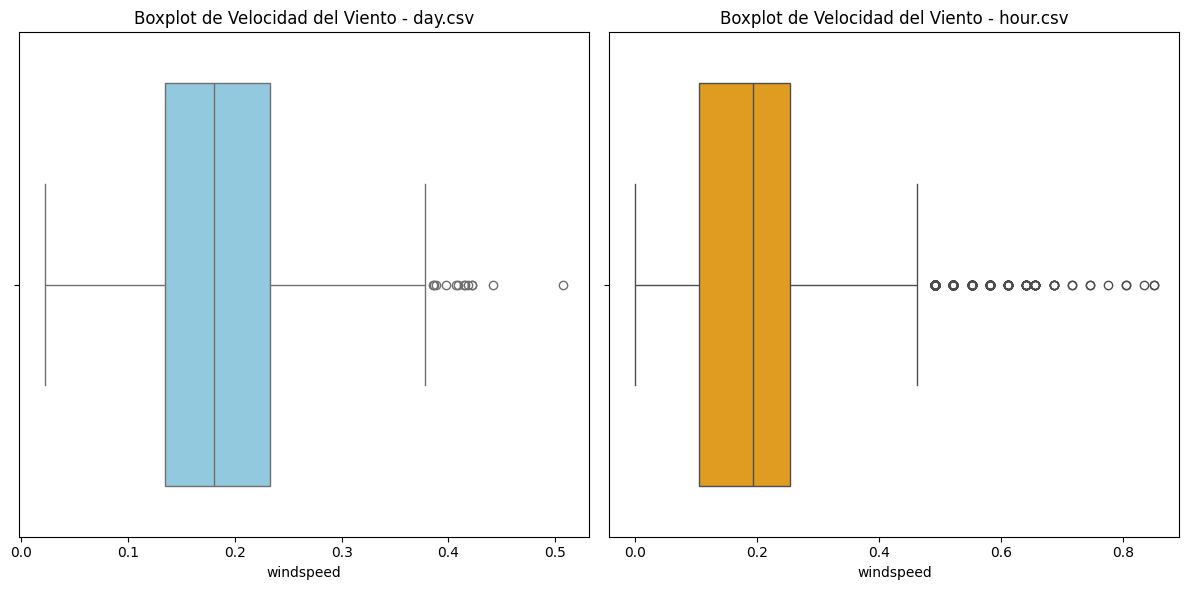

In [13]:
# BOXPLOT PARA 'windspeed'
plt.figure(figsize=(12, 6))

#en day.csv
plt.subplot(1, 2, 1)
sns.boxplot(x=day_data['windspeed'], color='skyblue')
plt.title('Boxplot de Velocidad del Viento - day.csv')
plt.xlabel('windspeed')

#en hour.csv
plt.subplot(1, 2, 2)
sns.boxplot(x=hour_data['windspeed'], color='orange')
plt.title('Boxplot de Velocidad del Viento - hour.csv')
plt.xlabel('windspeed')

plt.tight_layout()
plt.show()

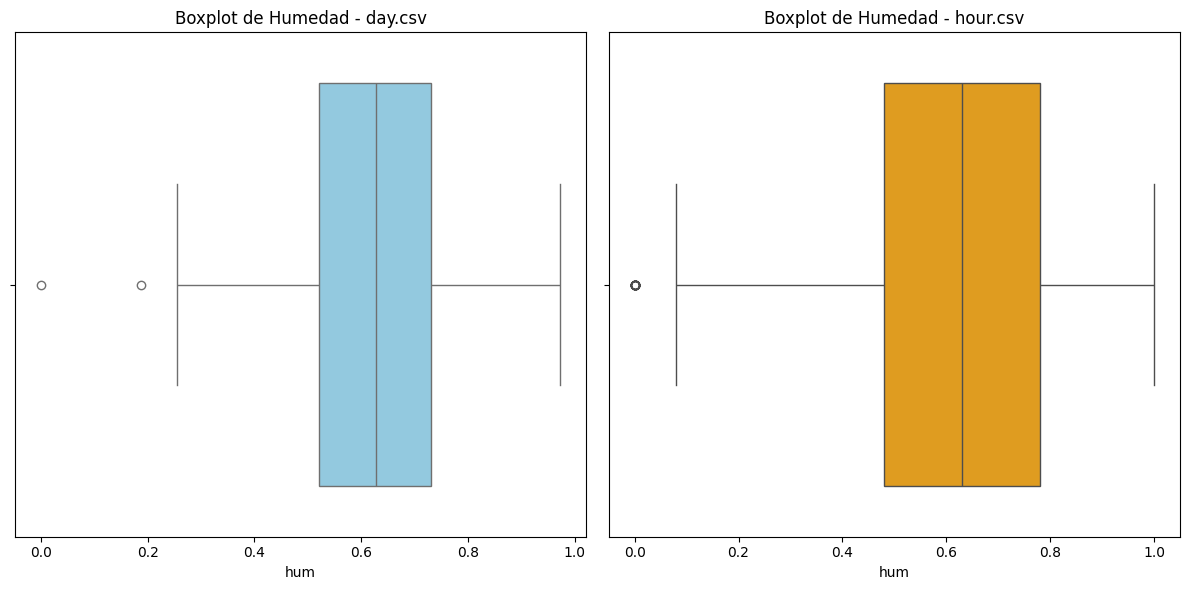

In [14]:
# BOXPLOT PARA 'hum'
plt.figure(figsize=(12, 6))

#en day.csv
plt.subplot(1, 2, 1)
sns.boxplot(x=day_data['hum'], color='skyblue')
plt.title('Boxplot de Humedad - day.csv')
plt.xlabel('hum')

#en hour.csv
plt.subplot(1, 2, 2)
sns.boxplot(x=hour_data['hum'], color='orange')
plt.title('Boxplot de Humedad - hour.csv')
plt.xlabel('hum')

plt.tight_layout()
plt.show()

Vemos que, tal y como esprábamos, existen puntos extremos tanto en humedad como en la velocidad del viento en ambos datasets. Sin embargo, tomamos la decisión de que estos puntos no son preocupantes, ya que puede haber días con una humedad muy baja y, por tanto, cercana a 0 y días con mucho viento. Además, comprobamos que los puntos extremos son coherentes ya que están entre 0 y 1. Decidimos dejar los outliers tal y como están.

## Visualización y estudio de los datos

Una vez preprocesados los datos, hacemos visualizaciones para estudiar y entender mejor los datos con los que estamos trabajndo.

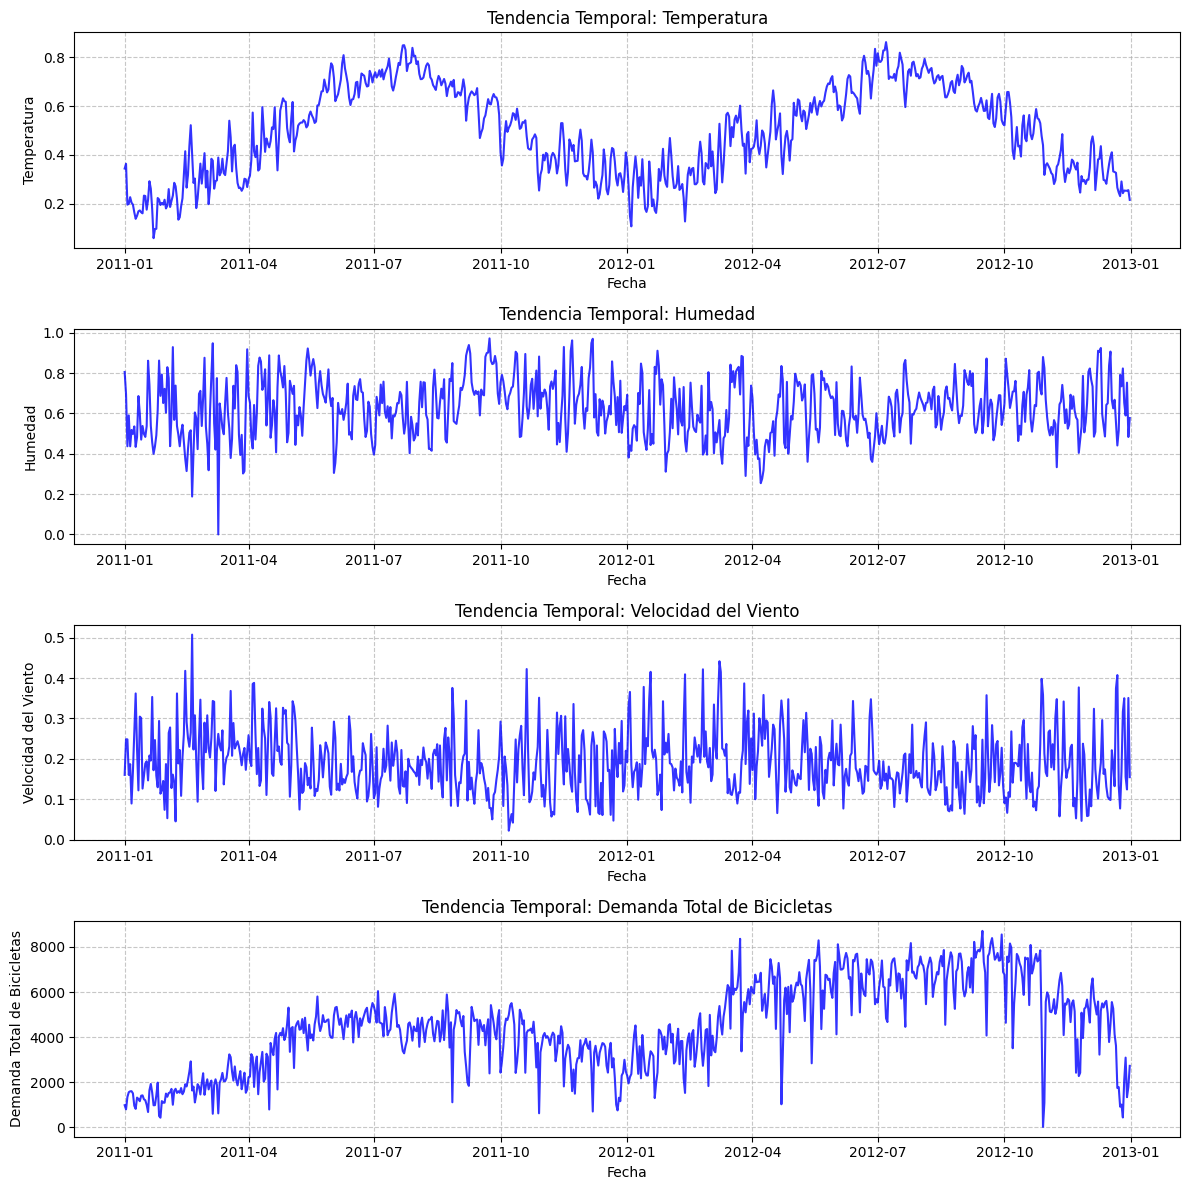

In [15]:
variables = {
    'temp': 'Temperatura',
    'hum': 'Humedad',
    'windspeed': 'Velocidad del Viento',
    'cnt': 'Demanda Total de Bicicletas'
}

plt.figure(figsize=(12, 12))

for i, (var, label) in enumerate(variables.items(), start=1):
    plt.subplot(4, 1, i)
    plt.plot(day_data['dteday'], day_data[var], label=label, color='blue', alpha=0.8)
    plt.title(f"Tendencia Temporal: {label}")
    plt.xlabel("Fecha")
    plt.ylabel(label)
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    plt.tight_layout()

plt.show()

**1. Temperatura**

Podemos ver un claro patrón estacional, con picos evidentes en verano y mínimos en inviernos. Obviamente esta variable afecta con respecto a la demanda de las bicicletas a lo largo del año, con un buen tiempo la demanda crece mientras que con condiciones meteorológicas malas, la demanda decrece. 


**2. Humedad** 

Esta variable muestra valores más constantes sin un patrón estacional claro, aunque es posible apreciar niveles ligeramente más altos en invierno. 

**3. Velocidad del Viento**

Esta variable nos sorprende bastante, con muchos picos por toda la gráfica sin seguir un patrón definido. Es posible que los días con vientos más fuertes afecten negativamente a la demanda de bicicletas.

**4. Demanda Total de Bicicletas** 

Como habíamos dicho, la demanda muestra una relación positiva con la temperatura. Aumenta en primavera y verano mientras que disminuye en invierno y otoño.

Procedemos a estudiar el impacto de los valores atípicos del viento en la demanda

In [16]:
# Outliers detectados en el preprocesamiento
q1 = day_data['windspeed'].quantile(0.25)
q3 = day_data['windspeed'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# Filtramos los outliers y su impacto en la demanda
outliers = day_data[day_data['windspeed'] > upper_bound]
impact_outliers = outliers['cnt'].describe()

# Comparamos los no outliers
non_outliers = day_data[day_data['windspeed'] <= upper_bound]
impact_non_outliers = non_outliers['cnt'].describe()

print(f"Demanda con los valores atípicos:\n{impact_outliers}\n---------------\nSin valores atípicos:\n{impact_non_outliers}")

Demanda con los valores atípicos:
count      13.000000
mean     3231.307692
std      1471.742130
min      1529.000000
25%      1795.000000
50%      3115.000000
75%      4459.000000
max      5558.000000
Name: cnt, dtype: float64
---------------
Sin valores atípicos:
count     718.000000
mean     4527.398329
std      1937.695290
min        22.000000
25%      3206.500000
50%      4566.500000
75%      6021.250000
max      8714.000000
Name: cnt, dtype: float64


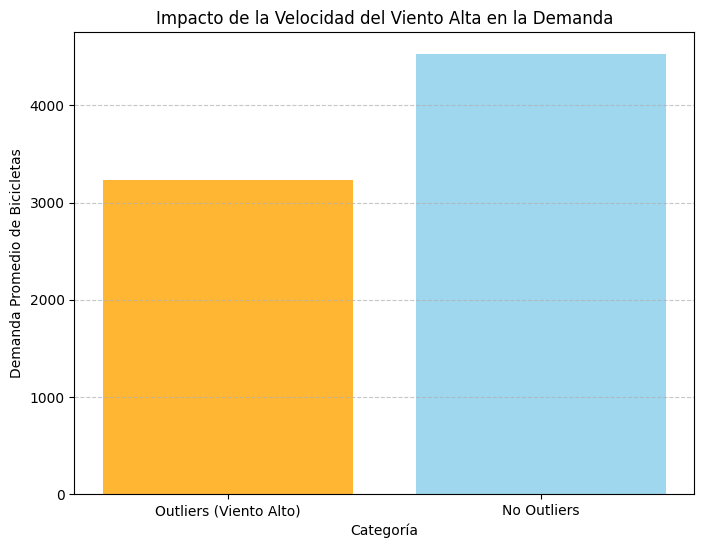

In [17]:
plt.figure(figsize=(8, 6))

# Demanda promedio con y sin outliers
avg_demand = [outliers['cnt'].mean(), non_outliers['cnt'].mean()]
categories = ['Outliers (Viento Alto)', 'No Outliers']


plt.bar(categories, avg_demand, color=['orange', 'skyblue'], alpha=0.8)
plt.title("Impacto de la Velocidad del Viento Alta en la Demanda")
plt.ylabel("Demanda Promedio de Bicicletas")
plt.xlabel("Categoría")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Analizando los datos que hemos obtenido tanto gráfica como analiticamente, llegamos a la conclusión de que, tal y como habíamos previsto, la velocidad del viento afecta mucho a la demanda de bicicletas, ya que vemos que los días con velocidades de viento muy altas tienen una media de demanda de 1500 bicicletas menos, aproximadamente.

Ahora analicemos la demada por temporadas estacionales: PRIMAVERA, VERANO, OTOÑO e INVIERNO.

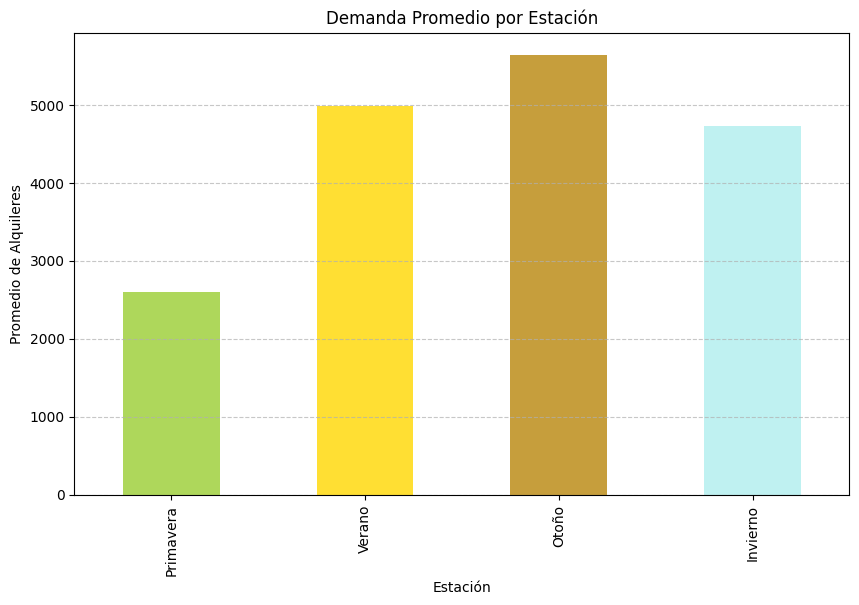

,avg_demand,avg_temp,avg_humidity,avg_windspeed
Primavera,2604.132597,0.297748,0.582903,0.214537
Verano,4992.331522,0.544405,0.626948,0.203507
Otoño,5644.303191,0.706309,0.633482,0.172095
Invierno,4728.162921,0.422906,0.668719,0.171995


In [18]:
seasonal_data = day_data.groupby('season').agg(
    avg_demand=('cnt', 'mean'),
    avg_temp=('temp', 'mean'),
    avg_humidity=('hum', 'mean'),
    avg_windspeed=('windspeed', 'mean')
)

seasonal_data.index = ['Primavera', 'Verano', 'Otoño', 'Invierno']


plt.figure(figsize=(10, 6))
seasonal_data['avg_demand'].plot(kind='bar', color=['yellowgreen', 'gold', 'darkgoldenrod', 'paleturquoise'], alpha=0.8)
plt.title("Demanda Promedio por Estación")
plt.ylabel("Promedio de Alquileres")
plt.xlabel("Estación")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

seasonal_data

- **Demanda promedio por estación:**
  - **Primavera:** Baja demanda (2604 alquileres promedio).
  - **Verano:** Aumenta significativamente (4992 alquileres promedio).
  - **Otoño:** Mayor demanda (5644 alquileres promedio).
  - **Invierno:** Disminuye ligeramente respecto al otoño (4728 alquileres promedio).

- **Condiciones climáticas promedio:**
  - **Temperatura:**
    - Más alta en otoño (0.71) y verano (0.54) y más baja en primavera (0.30).
  - **Humedad:**
    - Más alta en invierno (0.67).
  - **Velocidad del viento:**
    - Similar en todas las estaciones, siendo más baja en otoño e invierno.

En conclusión, Otoño parece ser la estación con mayor demanda de bicicletas, probablemente debido a temperaturas agradables y menos viento.En cuanto a la Primavera, es la que menordemanda tiene.
Los factores climáticos (especialmente temperatura y viento) parecen ser clave en las fluctuaciones de la demanda.

Ahora, queremos comprobar si que el día sea un día entre semana o fin de semana afecta en algo a la demanda de bicicletas.

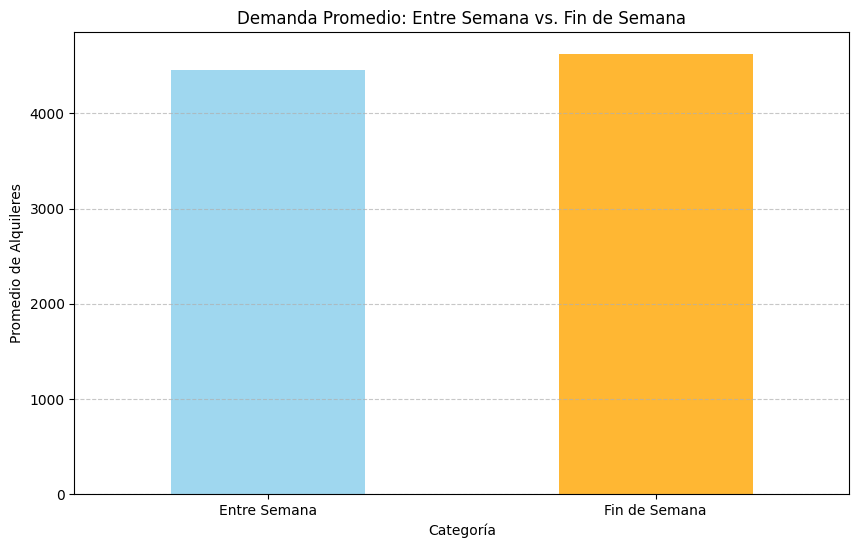

,avg_demand,avg_temp,avg_humidity,avg_windspeed
Entre Semana,4458.011494,0.498029,0.632387,0.190075
Fin de Semana,4620.081340,0.488781,0.616672,0.191513


In [19]:
day_data_copy = day_data.copy()
day_data_copy['is_weekend'] = day_data_copy['weekday'].apply(lambda x: 1 if x >= 5 else 0)

weekend_data = day_data_copy.groupby('is_weekend').agg(
    avg_demand=('cnt', 'mean'),
    avg_temp=('temp', 'mean'),
    avg_humidity=('hum', 'mean'),
    avg_windspeed=('windspeed', 'mean')
)

weekend_data.index = ['Entre Semana', 'Fin de Semana']

plt.figure(figsize=(10, 6))
weekend_data['avg_demand'].plot(kind='bar', color=['skyblue', 'orange'], alpha=0.8)
plt.title("Demanda Promedio: Entre Semana vs. Fin de Semana")
plt.ylabel("Promedio de Alquileres")
plt.xlabel("Categoría")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

weekend_data

Vemos que, aunque la diferencia no sea significativa, hay menor demanda media en días entre semana que en fin de semana. Esto se puede deber a que la gente no tiene que ir a trabajar o al centro educativo lo que hace posible una mayor movilización para practicar actividades diferentes que promueven el uso de la bicicleta para desplazarse.

Visualizamos la diferencia de uso en cada hora del día diferenciando entre días entre semana y fin de semana.

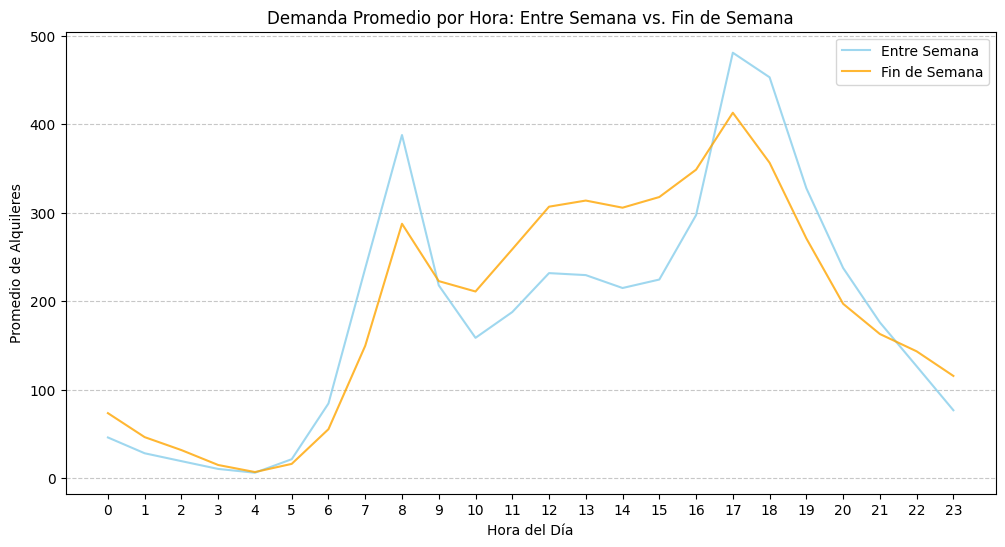

In [20]:
hour_data_copy = hour_data.copy()
hour_data_copy['is_weekend'] = hour_data_copy['weekday'].apply(lambda x: 1 if x >= 5 else 0)
hourly_weekend_data = hour_data_copy.groupby(['hr', 'is_weekend']).agg(avg_demand=('cnt', 'mean')).reset_index()
weekday_hourly = hourly_weekend_data[hourly_weekend_data['is_weekend'] == 0]
weekend_hourly = hourly_weekend_data[hourly_weekend_data['is_weekend'] == 1]

plt.figure(figsize=(12, 6))
plt.plot(weekday_hourly['hr'], weekday_hourly['avg_demand'], label='Entre Semana', color='skyblue', alpha=0.8)
plt.plot(weekend_hourly['hr'], weekend_hourly['avg_demand'], label='Fin de Semana', color='orange', alpha=0.8)
plt.title("Demanda Promedio por Hora: Entre Semana vs. Fin de Semana")
plt.xlabel("Hora del Día")
plt.ylabel("Promedio de Alquileres")
plt.xticks(range(0, 24, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

**Entre semana**: Se aprecia que el pico de demanda es muy pronunciado a las 8:00 y 17:00 horas, reflejando los horarios típicos de entrada y salida del trabajo, descendiendo significativamente después de las 18:00.

**Fin de semana**: La demanda es más uniforme, con un aumento progresivo desde las 9:00 hasta un pico en torno a las 16:00.

En cuánto a la demanda por Día de la Semana, observamos que los días con más demanda son el **Viernes** y el **Sábado**:

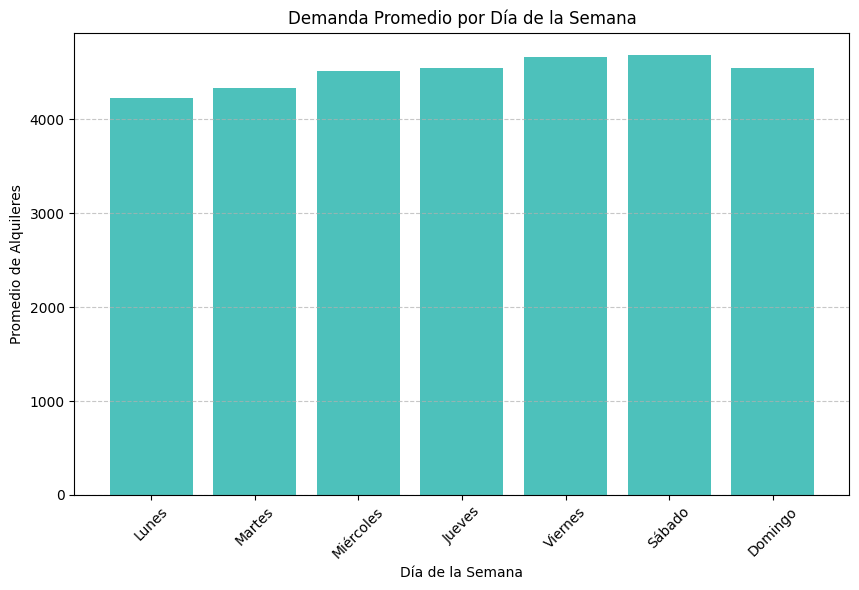

,weekday,avg_demand
0,Lunes,4228.828571
1,Martes,4338.123810
2,Miércoles,4510.663462
3,Jueves,4548.538462
4,Viernes,4667.259615
5,Sábado,4690.288462
6,Domingo,4550.542857


In [21]:
weekday_demand = day_data.groupby('weekday').agg(avg_demand=('cnt', 'mean')).reset_index()
weekday_demand['weekday'] = weekday_demand['weekday'].replace({ 0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'})

plt.figure(figsize=(10, 6))
plt.bar(weekday_demand['weekday'], weekday_demand['avg_demand'], color='lightseagreen', alpha=0.8)
plt.title("Demanda Promedio por Día de la Semana")
plt.xlabel("Día de la Semana")
plt.ylabel("Promedio de Alquileres")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()


weekday_demand

Visualizamos la diferencia entre usuarios registrados y no registrados a la hora de alquilar bicicletas.

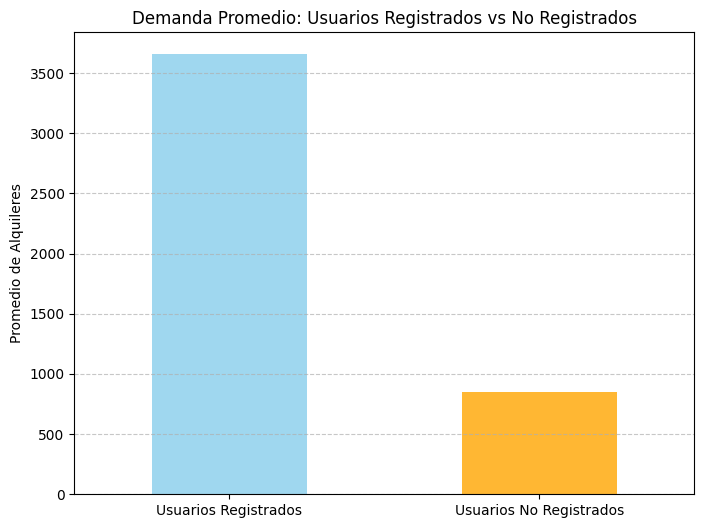

In [22]:
user_type_demand = day_data[['registered', 'casual']].mean()

plt.figure(figsize=(8, 6))
user_type_demand.plot(kind='bar', color=['skyblue', 'orange'], alpha=0.8)
plt.title("Demanda Promedio: Usuarios Registrados vs No Registrados")
plt.ylabel("Promedio de Alquileres")
plt.xticks(ticks=[0, 1], labels=['Usuarios Registrados', 'Usuarios No Registrados'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Como era de esperar, los usuarios registrados son en su mayoría los que usan este sistema de alquiler de bicicletas mientras que los no registrados representan la minoría. Siendo estos últimos usuarios ocasionales. 

Por último, visualizamos las variables que creamos en el preprocesamiento.

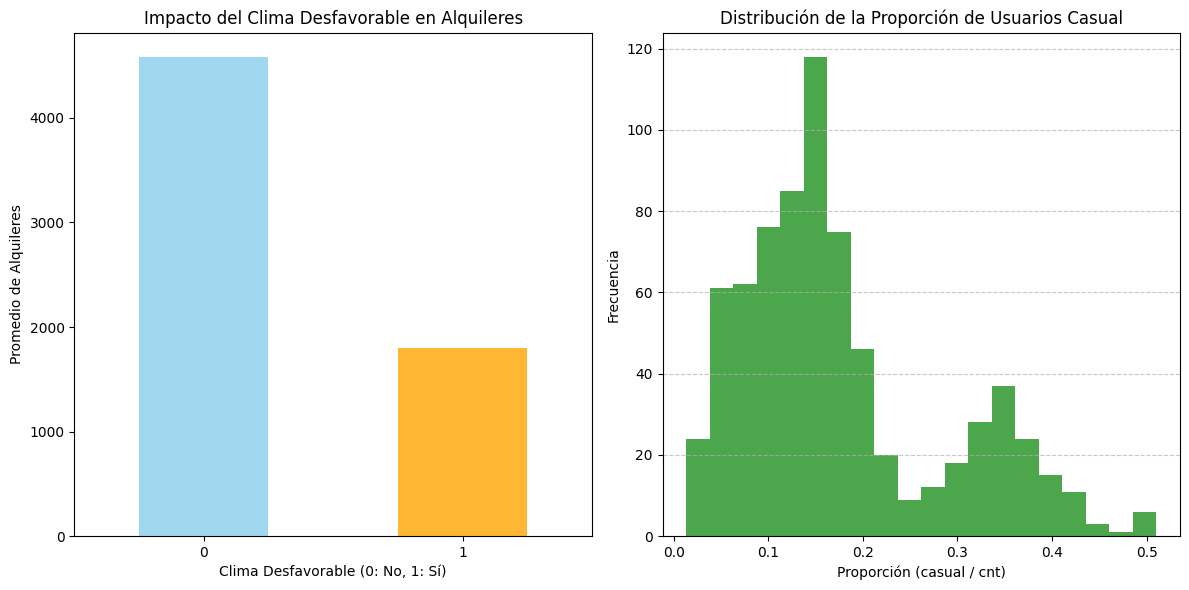

In [23]:
plt.figure(figsize=(12, 6))

#Pra la variable bad_weather
plt.subplot(1, 2, 1)
bad_weather_impact = day_data.groupby('bad_weather')['cnt'].mean()
bad_weather_impact.plot(kind='bar', color=['skyblue', 'orange'], alpha=0.8)
plt.title("Impacto del Clima Desfavorable en Alquileres")
plt.xlabel("Clima Desfavorable (0: No, 1: Sí)")
plt.ylabel("Promedio de Alquileres")
plt.xticks(rotation=0)

# Para la variable casual_ratio
plt.subplot(1, 2, 2)
plt.hist(day_data['casual_ratio'], bins=20, color='green', alpha=0.7)
plt.title("Distribución de la Proporción de Usuarios Casual")
plt.xlabel("Proporción (casual / cnt)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1. **Impacto del clima desfavorable (`bad_weather`) en los alquileres:**
   - En días con clima desfavorable (`bad_weather = 1`), el promedio de alquileres es significativamente menor que en días con buen clima (`bad_weather = 0`).
   - Esto confirma que las condiciones climáticas adversas reducen la demanda.

2. **Distribución de la proporción de usuarios casuales (`casual_ratio`):**
   - La mayoría de los días tienen una proporción baja de usuarios casuales respecto al total de alquileres (entre 0.05 y 0.2).
   - Solo en casos excepcionales los usuarios casuales representan más del 40% de los alquileres.

## Selección de características
Para elegir las características con las que queremos entrenar nuestro modelo visualizamos la correlación de cada una de las variables con `cnt`. Es decir, visualizamos la parte de la matriz de correlación que nos interesa para elegir las características.

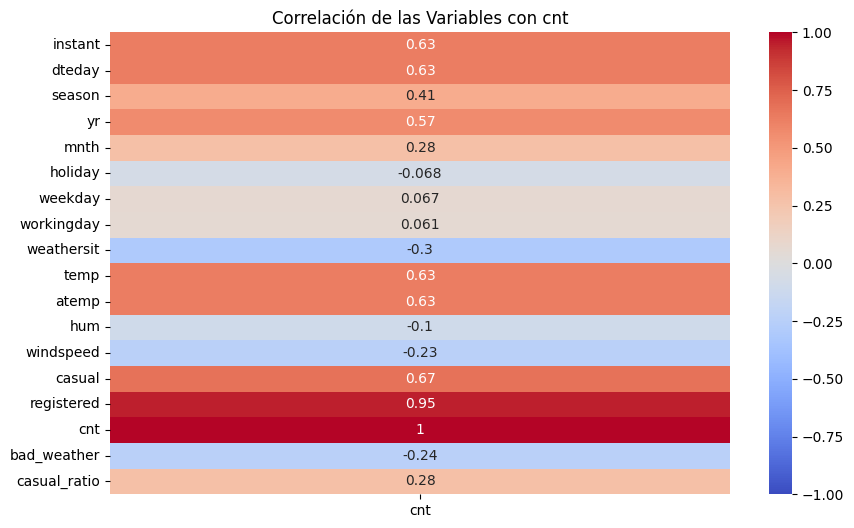

In [24]:
correlation_matrix = day_data.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix[['cnt']], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de las Variables con cnt')
plt.show()

Como podemos observar, las variables holiday, weekday, workingday, hum, mnth y casual_ratio apenas están correlacionadas con la variable `cnt`, por lo que las eliminaremos para simplificar el modelo. Por su parte, registered está altamente correlacionada con `cnt`, por lo que, para evitar multicolinealidad, vamos a eliminarla también.

In [25]:
day_data = day_data.drop(columns=['holiday', 'weekday', 'workingday', 'hum', 'registered', 'mnth', 'casual_ratio'])
day_data.head()

,instant,dteday,season,yr,weathersit,temp,atemp,windspeed,casual,cnt,bad_weather
0,1,2011-01-01,1,0,2,0.344167,0.363625,0.160446,331,985,0
1,2,2011-01-02,1,0,2,0.363478,0.353739,0.248539,131,801,0
2,3,2011-01-03,1,0,1,0.196364,0.189405,0.248309,120,1349,0
3,4,2011-01-04,1,0,1,0.200000,0.212122,0.160296,108,1562,0
4,5,2011-01-05,1,0,1,0.226957,0.229270,0.186900,82,1600,0


## Análisis de series temporales
Para empezar el análisis, simplemente visualizamos la serie temporal.

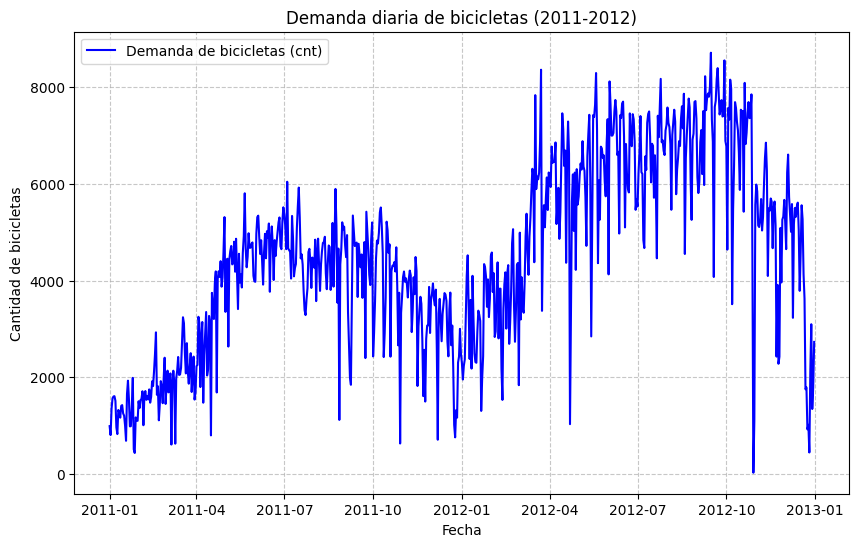

In [26]:
# Establecemos 'dteday' como índice
day_data.set_index('dteday', inplace=True)

# Modelamos la serie temporal
time_series = day_data['cnt']

plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Demanda de bicicletas (cnt)', color='blue')
plt.title('Demanda diaria de bicicletas (2011-2012)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de bicicletas')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Después, observamos la descomposición de la serie.

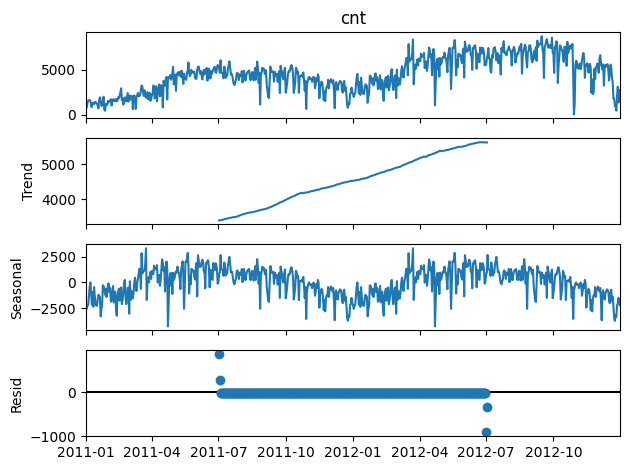

In [27]:
result = seasonal_decompose(time_series, model='additive', period=365)
result.plot()
plt.show()

Como podemos observar en la descomposición de la serie, hay una clara tendencia positiva en los datos, una estacionaridad al haber picos que se repiten, y los residuos están alrededor del 0, lo que en un principio es algo positivo, pero se pueden apreciar algunos valores extremos, los cuales trataremos más adelante.

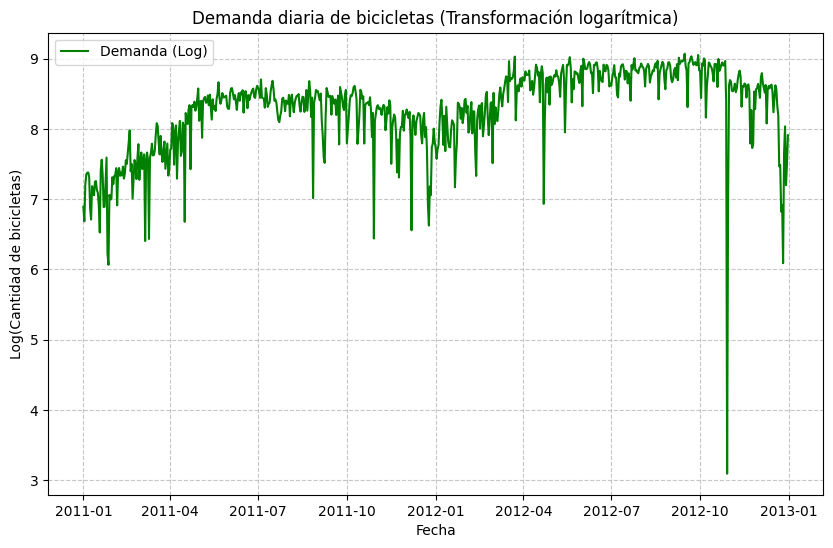

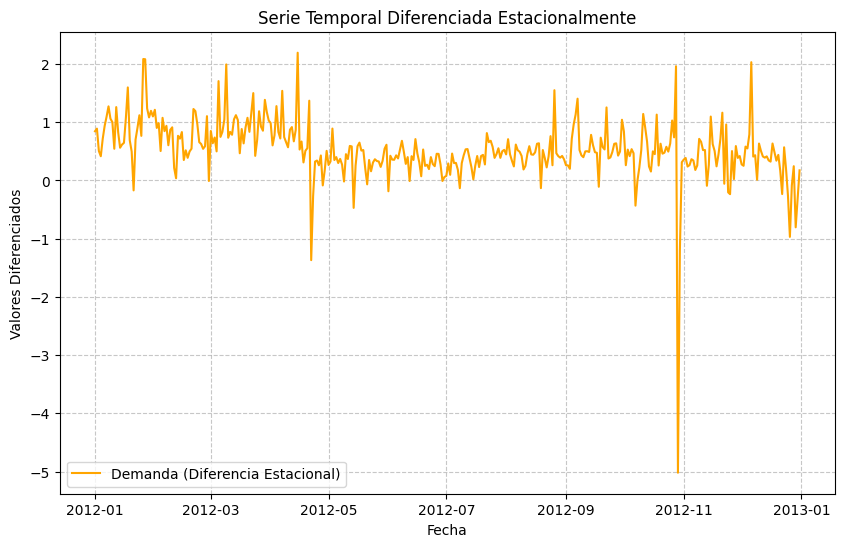

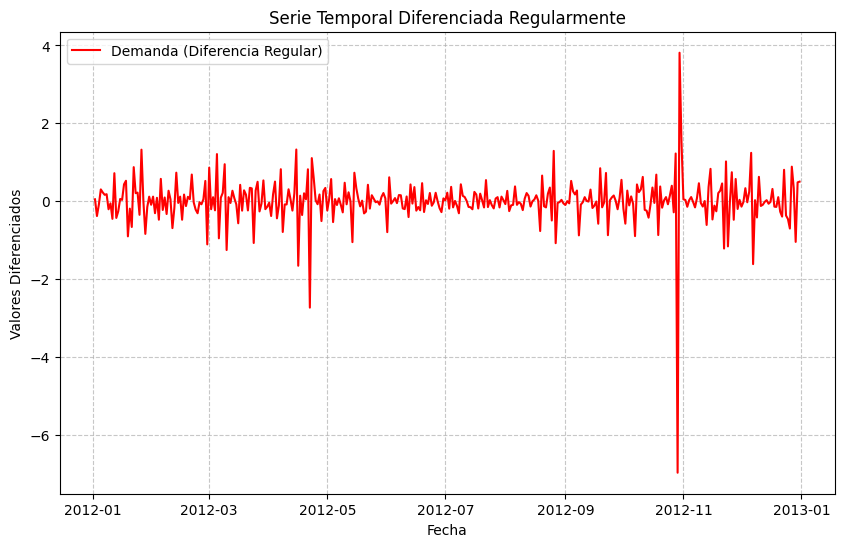

In [28]:
# Transformación logarítmica
log_time_series = np.log(time_series)

plt.figure(figsize=(10, 6))
plt.plot(log_time_series, label='Demanda (Log)', color='green')
plt.title('Demanda diaria de bicicletas (Transformación logarítmica)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Diferenciación estacional para eliminar patrones anuales (lag=365/12 meses)
seasonal_diff = log_time_series.diff(365).dropna()

# Visualizar la serie diferenciada estacionalmente
plt.figure(figsize=(10, 6))
plt.plot(seasonal_diff, label='Demanda (Diferencia Estacional)', color='orange')
plt.title('Serie Temporal Diferenciada Estacionalmente')
plt.xlabel('Fecha')
plt.ylabel('Valores Diferenciados')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Diferenciación regular para eliminar tendencias
regular_diff = seasonal_diff.diff().dropna()

# Visualizar la serie diferenciada regularmente
plt.figure(figsize=(10, 6))
plt.plot(regular_diff, label='Demanda (Diferencia Regular)', color='red')
plt.title('Serie Temporal Diferenciada Regularmente')
plt.xlabel('Fecha')
plt.ylabel('Valores Diferenciados')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Vemos en la serie final que hay algunos puntos muy extremos que pueden llegar a afectar el modelo, sin embargo, vamos a crear el modelo con puntos extremos y sin ellos para observar las diferencias y ver cuánto afectan estos puntos al modelo.

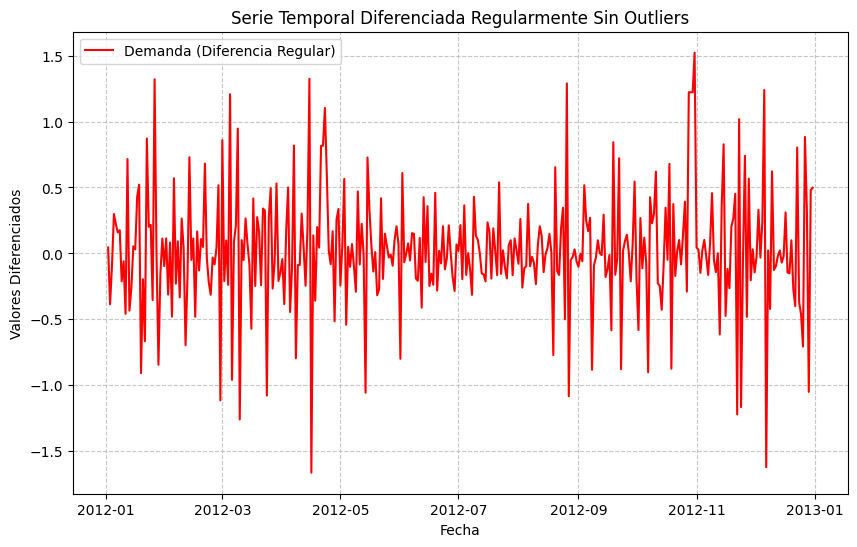

In [59]:
regular_diff_no_outliers = regular_diff[np.abs(regular_diff - regular_diff.mean()) < 3 * regular_diff.std()] 
regular_diff_no_outliers = regular_diff_no_outliers.asfreq('D') # establecemos la frecuencia diaria
regular_diff_no_outliers = regular_diff_no_outliers.fillna(method='ffill')  # rellenamos los nulos hacia delante
# regular_diff_no_outliers.loc[outliers.index]

plt.figure(figsize=(10, 6))
plt.plot(regular_diff_no_outliers, label='Demanda (Diferencia Regular)', color='red')
plt.title('Serie Temporal Diferenciada Regularmente Sin Outliers')
plt.xlabel('Fecha')
plt.ylabel('Valores Diferenciados')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Hacemos la prueba ADF para comprobar la estacionariedad de las series (tanto con puntos extremos como sin ellos).

Prueba ADF:
Estadístico ADF: -8.483610844357118
p-valor: 1.372005736039934e-13
Número de lags: 13
Número de observaciones usadas: 351
Valores críticos:
   1%: -3.44911857009962
   5%: -2.8698097654570507
   10%: -2.5711757061225153


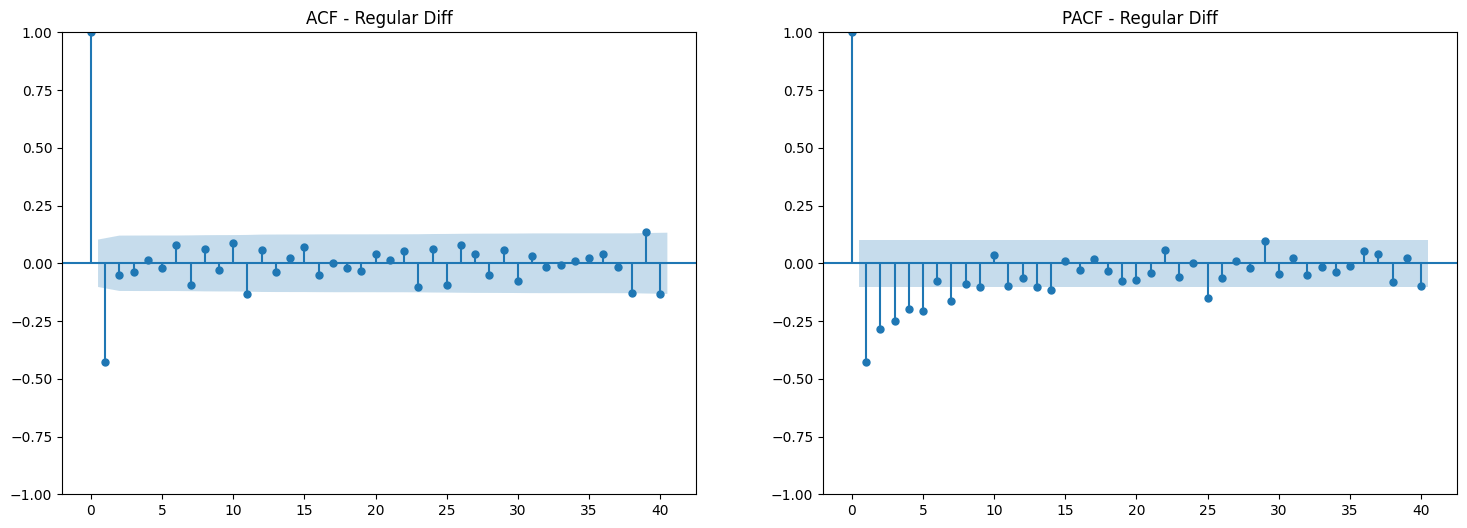

In [30]:
adf_result = adfuller(regular_diff)

print("Prueba ADF:")
print(f"Estadístico ADF: {adf_result[0]}")
print(f"p-valor: {adf_result[1]}")
print(f"Número de lags: {adf_result[2]}")
print(f"Número de observaciones usadas: {adf_result[3]}")
print("Valores críticos:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

plt.figure(figsize=(18,6))

# ACF
plt.subplot(121)
plot_acf(regular_diff.dropna(), lags=40, ax=plt.gca())
plt.title('ACF - Regular Diff')

# PACF
plt.subplot(122)
plot_pacf(regular_diff.dropna(), lags=40, ax=plt.gca())
plt.title('PACF - Regular Diff')

plt.show()

Los resultados han sido los siguientes:
* **Estadístico ADF:** -8.4836
* **p-valor:** 1.372e-13
* **Valores críticos:**
    - 1%: -3.4491
    - 5%: -2.8698
    - 10%: -2.5712

Esto nos muestra que la serie obtenida es estacionaria, por lo que la media, varianza y autocorrelación no cambian en el tiempo y, por lo tanto, es perfecta para métodos como ARIMA y SARIMA.

Prueba ADF:
Estadístico ADF: -24.834027421749074
p-valor: 0.0
Número de lags: 0
Número de observaciones usadas: 364
Valores críticos:
   1%: -3.4484434475193777
   5%: -2.869513170510808
   10%: -2.571017574266393


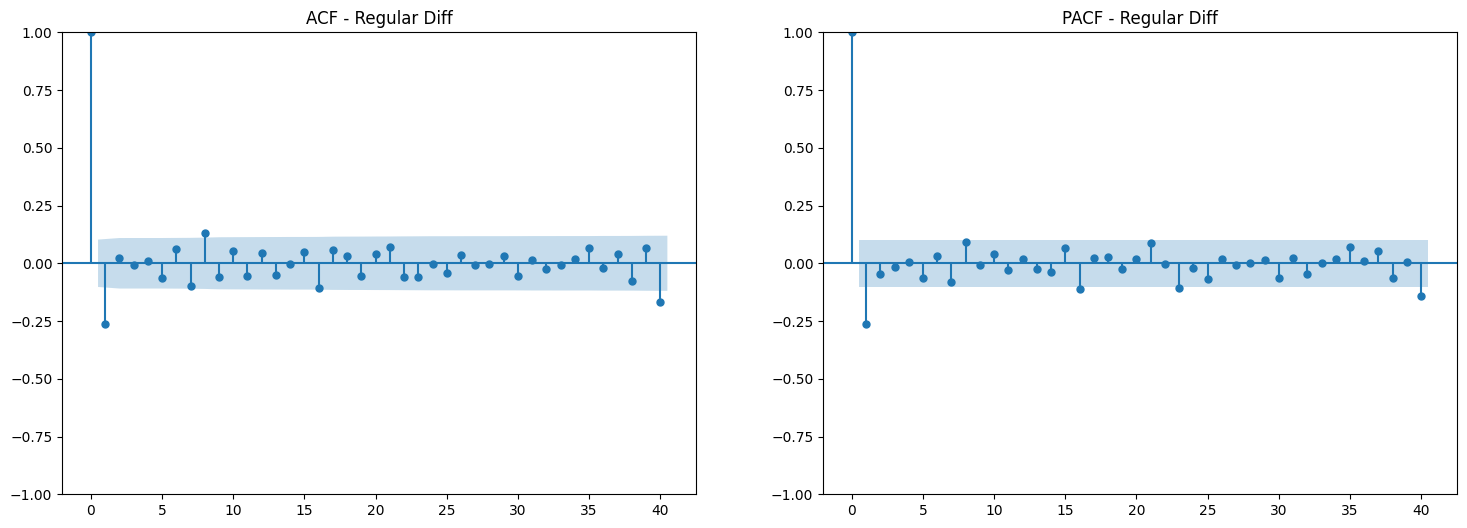

In [31]:
adf_result_no_outliers = adfuller(regular_diff_no_outliers)

print("Prueba ADF:")
print(f"Estadístico ADF: {adf_result_no_outliers[0]}")
print(f"p-valor: {adf_result_no_outliers[1]}")
print(f"Número de lags: {adf_result_no_outliers[2]}")
print(f"Número de observaciones usadas: {adf_result_no_outliers[3]}")
print("Valores críticos:")
for key, value in adf_result_no_outliers[4].items():
    print(f"   {key}: {value}")

plt.figure(figsize=(18,6))

# ACF
plt.subplot(121)
plot_acf(regular_diff_no_outliers.dropna(), lags=40, ax=plt.gca())
plt.title('ACF - Regular Diff')

# PACF
plt.subplot(122)
plot_pacf(regular_diff_no_outliers.dropna(), lags=40, ax=plt.gca())
plt.title('PACF - Regular Diff')

plt.show()

Los resultados han sido los siguientes:
* **Estadístico ADF:** -24.8340
* **p-valor:** 0.0
* **Valores críticos:**
    - 1%: -3.4484
    - 5%: -2.8695
    - 10%: -2.5710

Al igual que en la serie con outliers, comprobamos que la serie es estacionaria y, por tanto, podemos pasar a hacer los modelos ARIMA y SARIMA de ambas series.

## Modelo ARIMA
### Con puntos extremos

                               SARIMAX Results                                
Dep. Variable:                    cnt   No. Observations:                  365
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -256.680
Date:                Mon, 13 Jan 2025   AIC                            521.360
Time:                        13:43:15   BIC                            536.949
Sample:                    01-02-2012   HQIC                           527.556
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1329      0.055      2.430      0.015       0.026       0.240
ma.L1         -1.9347      0.290     -6.675      0.000      -2.503      -1.367
ma.L2          0.9347      0.269      3.470      0.0

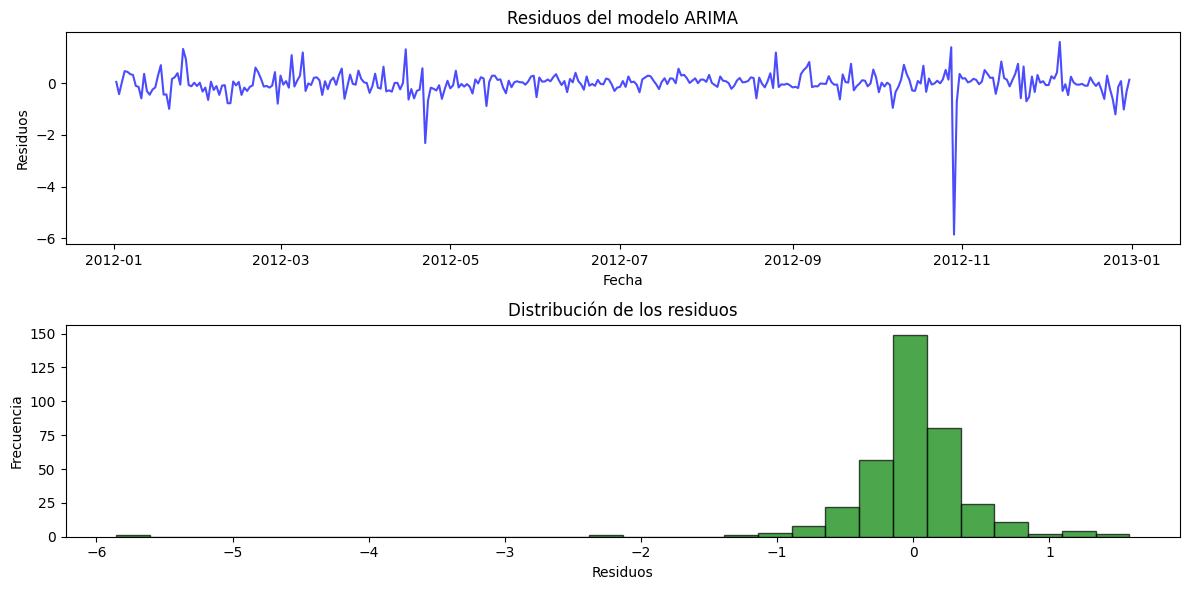

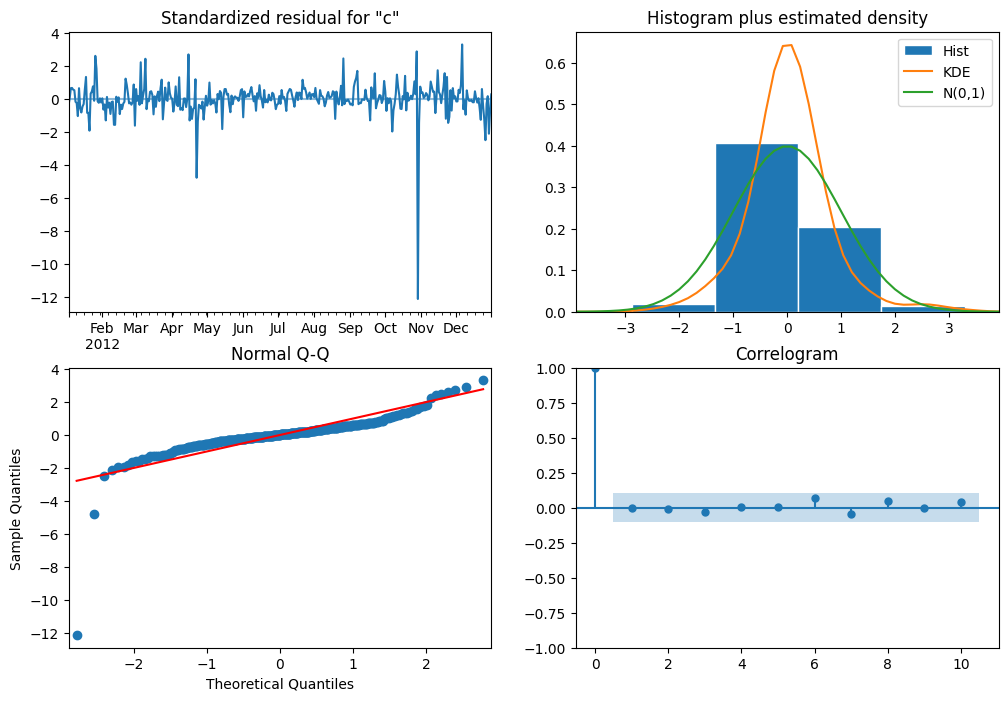

In [32]:
# ajustamos el modelo
model = ARIMA(regular_diff, order=(1, 1, 2))
model_fit = model.fit()

# imprimimos el resumen en pantalla
print(model_fit.summary())

# graficamos los residuos
residuals_arima = model_fit.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals_arima, color='blue', alpha=0.7)
plt.title('Residuos del modelo ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals_arima, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# validamos si los residuos son ruido blanco
model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

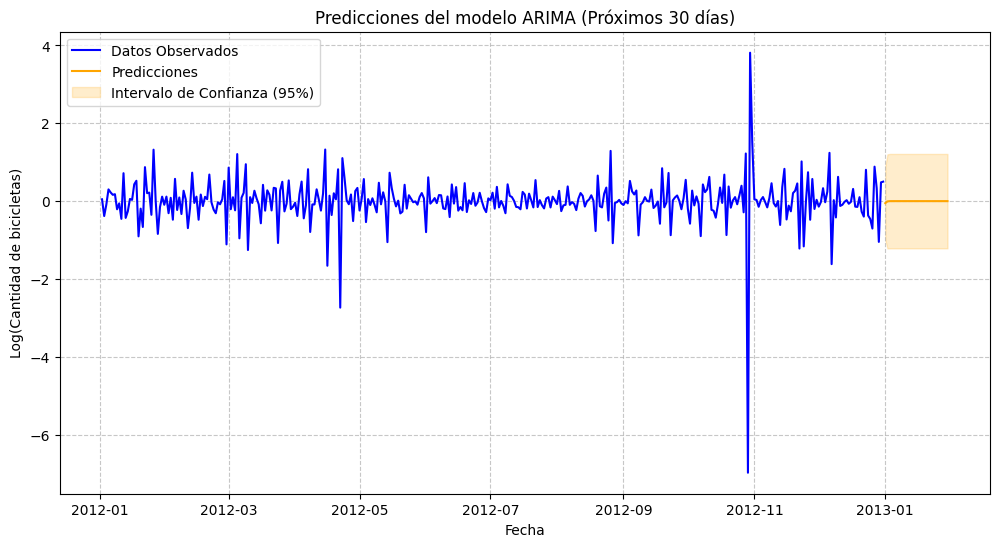

In [34]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps = 30  # Predecir los próximos 30 días
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

# Visualizar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(regular_diff, label='Datos Observados', color='blue')
plt.plot(forecast.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo ARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [35]:
y_true = regular_diff[-forecast_steps:]  # Valores reales
y_pred = forecast.predicted_mean  # Predicciones del modelo                                                                                 

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}, MAE: {mae}, R²: {r2}, RMSE: {rmse}")

MSE: 0.3093722388054407, MAE: 0.39586819730437534, R²: -0.0005608163572183855, RMSE: 0.5562124043973136


### Sin puntos extremos

                               SARIMAX Results                                
Dep. Variable:                    cnt   No. Observations:                  365
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -214.114
Date:                Tue, 14 Jan 2025   AIC                            434.228
Time:                        10:40:08   BIC                            445.919
Sample:                    01-02-2012   HQIC                           438.875
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2591      0.037     -7.011      0.000      -0.332      -0.187
ma.L1         -0.9999      0.491     -2.038      0.042      -1.962      -0.038
sigma2         0.1866      0.090      2.065      0.0

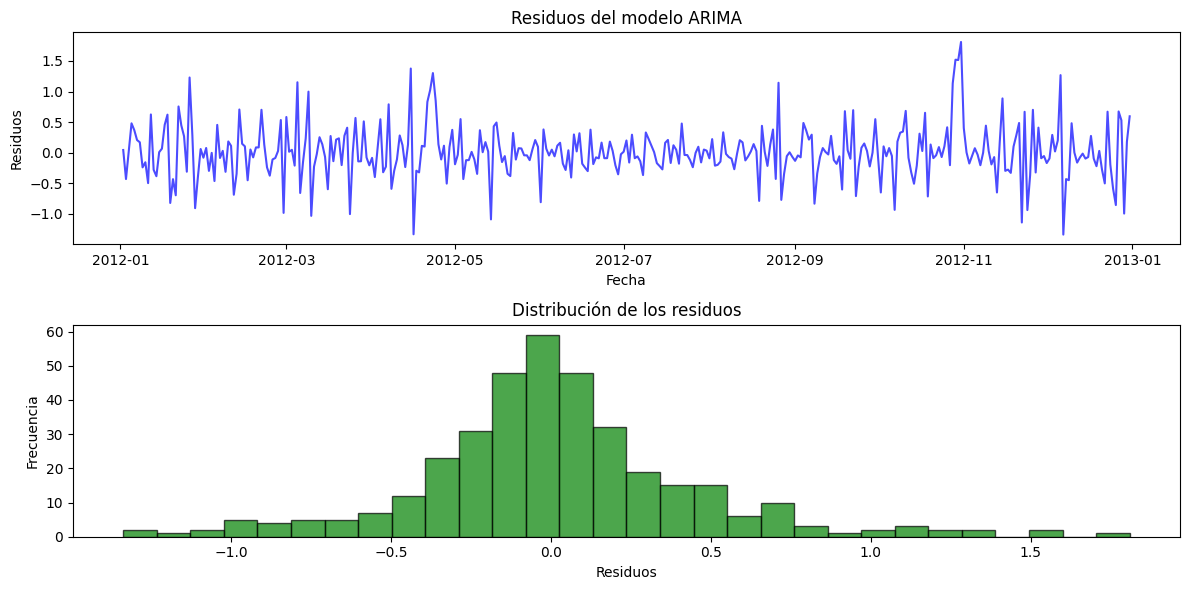

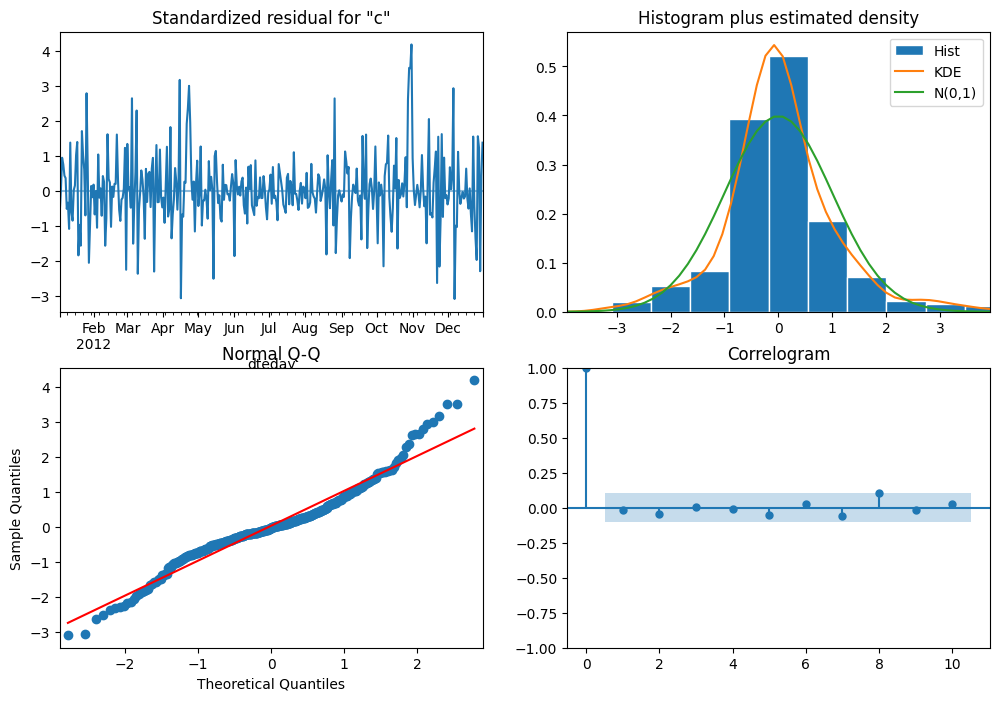

In [60]:
# ajustamos el modelo
model_no_outiers = ARIMA(regular_diff_no_outliers, order=(1, 1, 1))
model_fit_no_outliers = model_no_outiers.fit()

# imprimimos el resumen en pantalla
print(model_fit_no_outliers.summary())

# graficamos los residuos
residuals_arima_no_outliers = model_fit_no_outliers.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals_arima_no_outliers, color='blue', alpha=0.7)
plt.title('Residuos del modelo ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals_arima_no_outliers, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# validamos si los residuos son ruido blanco
model_fit_no_outliers.plot_diagnostics(figsize=(12, 8))
plt.show()

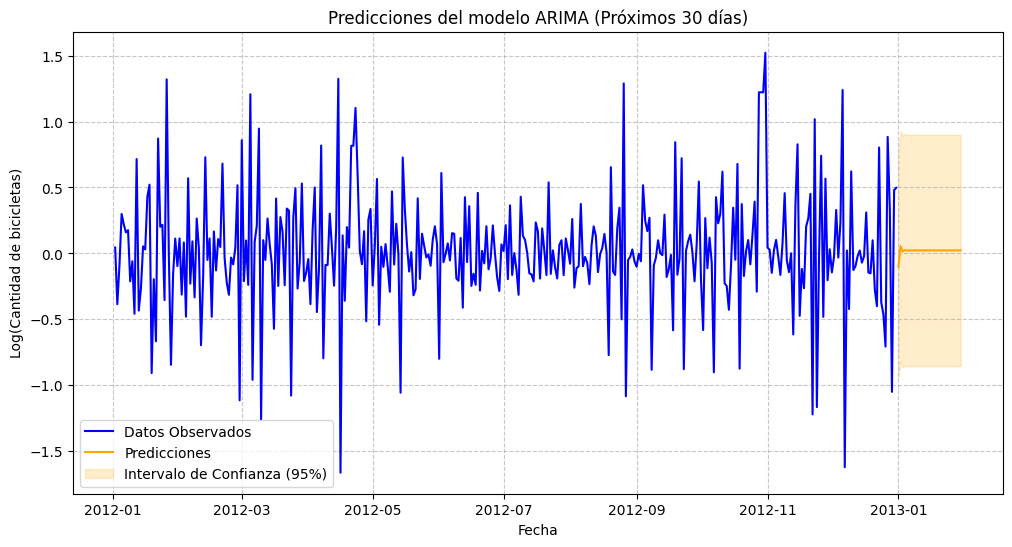

In [62]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps_no_outliers = 30  # Predecir los próximos 30 días
forecast_no_outliers = model_fit_no_outliers.get_forecast(steps=forecast_steps_no_outliers)
forecast_ci_no_outliers = forecast_no_outliers.conf_int()

# Visualizar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(regular_diff_no_outliers, label='Datos Observados', color='blue')
plt.plot(forecast_no_outliers.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci_no_outliers.index,
    forecast_ci_no_outliers.iloc[:, 0],
    forecast_ci_no_outliers.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo ARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [63]:
y_true_no_outliers = regular_diff_no_outliers[-forecast_steps_no_outliers:]  # Valores reales
y_pred_no_outliers = forecast_no_outliers.predicted_mean  # Predicciones del modelo                                                                                 

mse_no_outliers = mean_squared_error(y_true_no_outliers, y_pred_no_outliers)
mae_no_outliers = mean_absolute_error(y_true_no_outliers, y_pred_no_outliers)
r2_no_outliers = r2_score(y_true_no_outliers, y_pred_no_outliers)
rmse_no_outliers = np.sqrt(mse_no_outliers)

print(f"MSE: {mse_no_outliers}, MAE: {mae_no_outliers}, R²: {r2_no_outliers}, RMSE: {rmse_no_outliers}")

MSE: 0.30940022505683706, MAE: 0.39837259141893594, R²: -0.0006513285074101205, RMSE: 0.5562375617097762


## Modelo SARIMA 1
### Con puntos extremos

                                      SARIMAX Results                                       
Dep. Variable:                                  cnt   No. Observations:                  365
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 30)   Log Likelihood                -247.090
Date:                              Tue, 14 Jan 2025   AIC                            506.180
Time:                                      12:14:34   BIC                            528.423
Sample:                                  01-02-2012   HQIC                           515.081
                                       - 12-31-2012                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0866      0.058      1.499      0.134      -0.027       0.200
ma.L1         -1.93

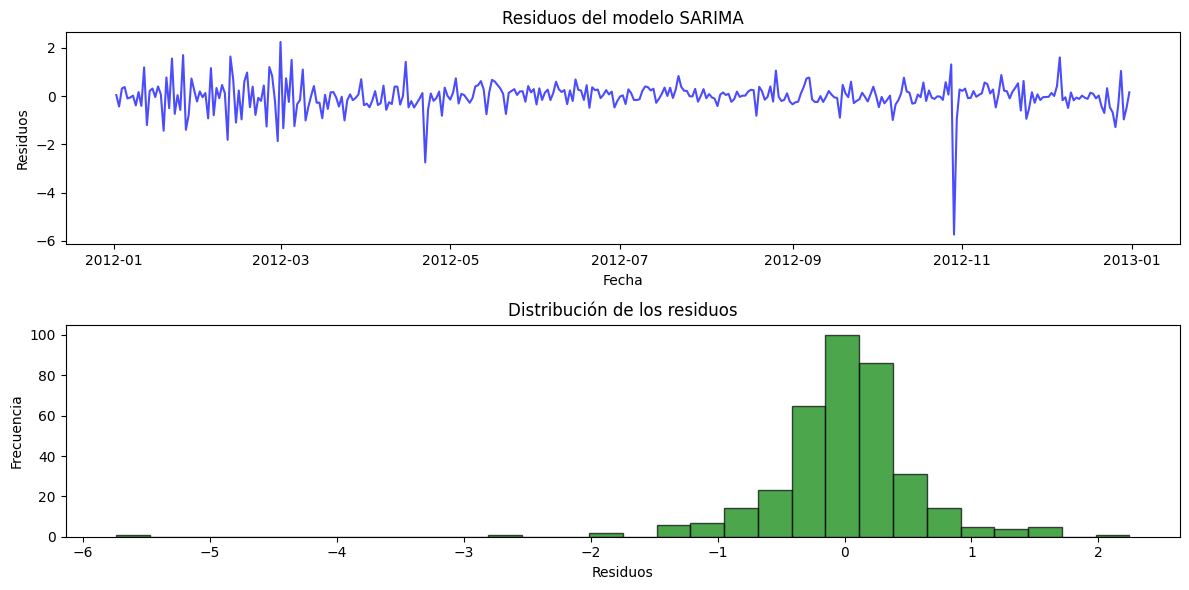

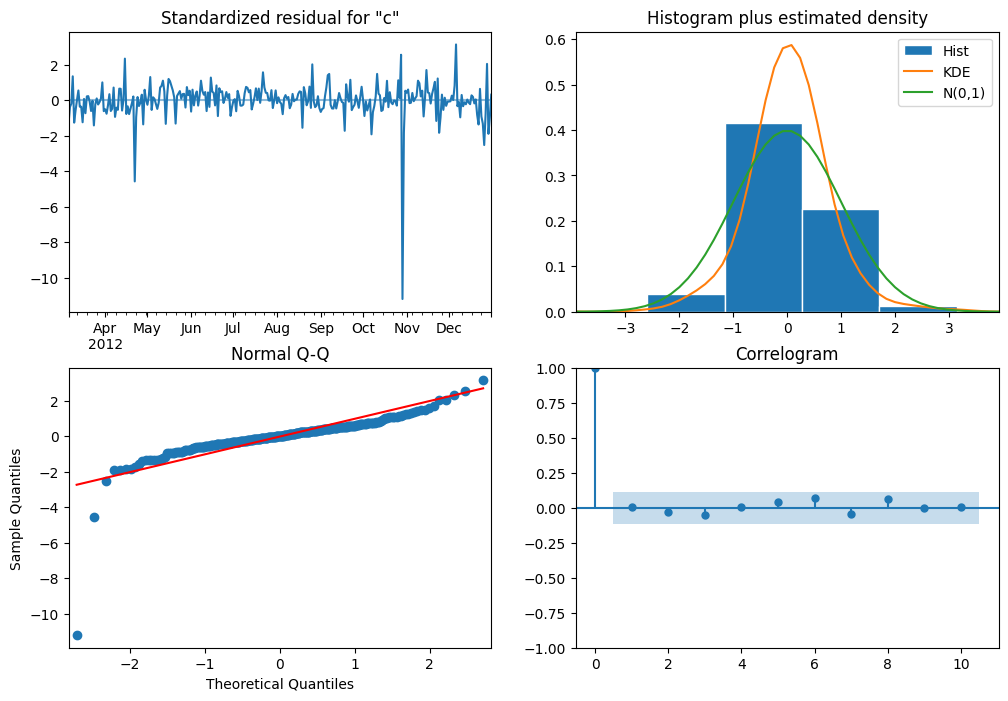

In [79]:
# Ajuste del modelo SARIMA inicial (valores iniciales basados en ACF y PACF)
model = SARIMAX(
    regular_diff,
    order=(1, 1, 2),  
    seasonal_order=(1, 1, 1, 30),  
    enforce_stationarity=False,
    enforce_invertibility=False,
)


sarima_result = model.fit(disp=False)


print(sarima_result.summary())


residuals = sarima_result.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals, color='blue', alpha=0.7)
plt.title('Residuos del modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validar si los residuos son ruido blanco
sarima_result.plot_diagnostics(figsize=(12, 8))
plt.show()

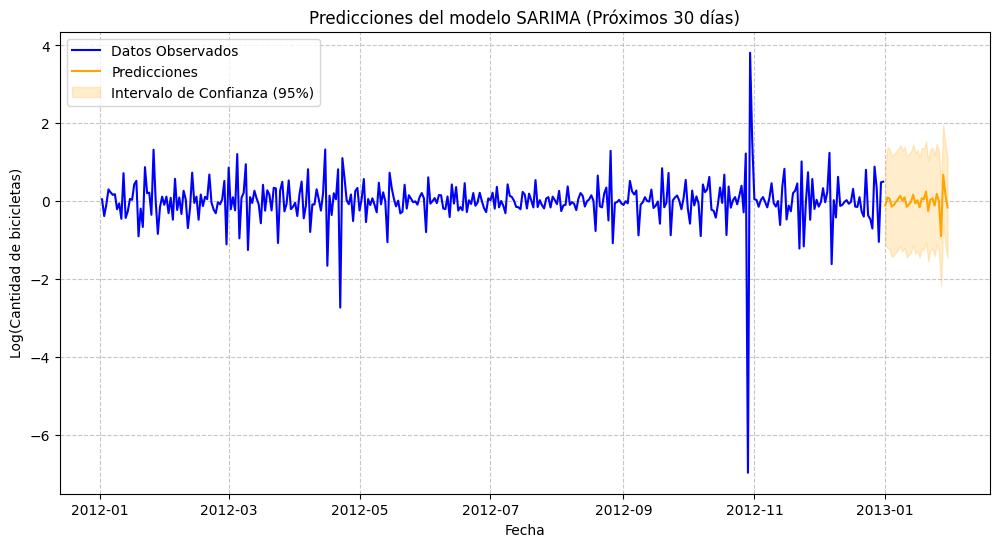

In [65]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps = 30  # Predecir los próximos 30 días
forecast = sarima_result.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()


plt.figure(figsize=(12, 6))
plt.plot(regular_diff, label='Datos Observados', color='blue')
plt.plot(forecast.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo SARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [66]:
y_true = regular_diff[-forecast_steps:]  # Valores reales
y_pred = forecast.predicted_mean  # Predicciones del modelo

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}, MAE: {mae}, R²: {r2}, RMSE: {rmse}" )

MSE: 0.4450260150616826, MAE: 0.4707506299791641, R²: -0.43928748956154307, RMSE: 0.6671027020344638


### Sin puntos extremos

                                     SARIMAX Results                                      
Dep. Variable:                                cnt   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood                -211.676
Date:                            Tue, 14 Jan 2025   AIC                            433.352
Time:                                    12:03:25   BIC                            451.904
Sample:                                01-02-2012   HQIC                           440.775
                                     - 12-31-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2748      0.047     -5.840      0.000      -0.367      -0.183
ma.L1         -1.0000     27.145   

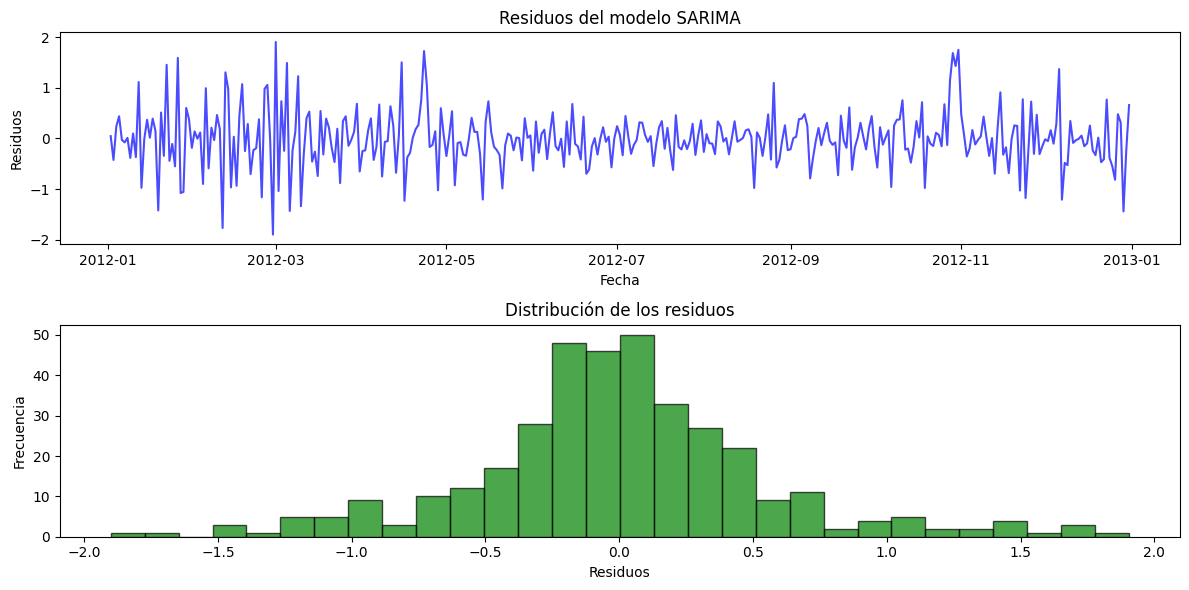

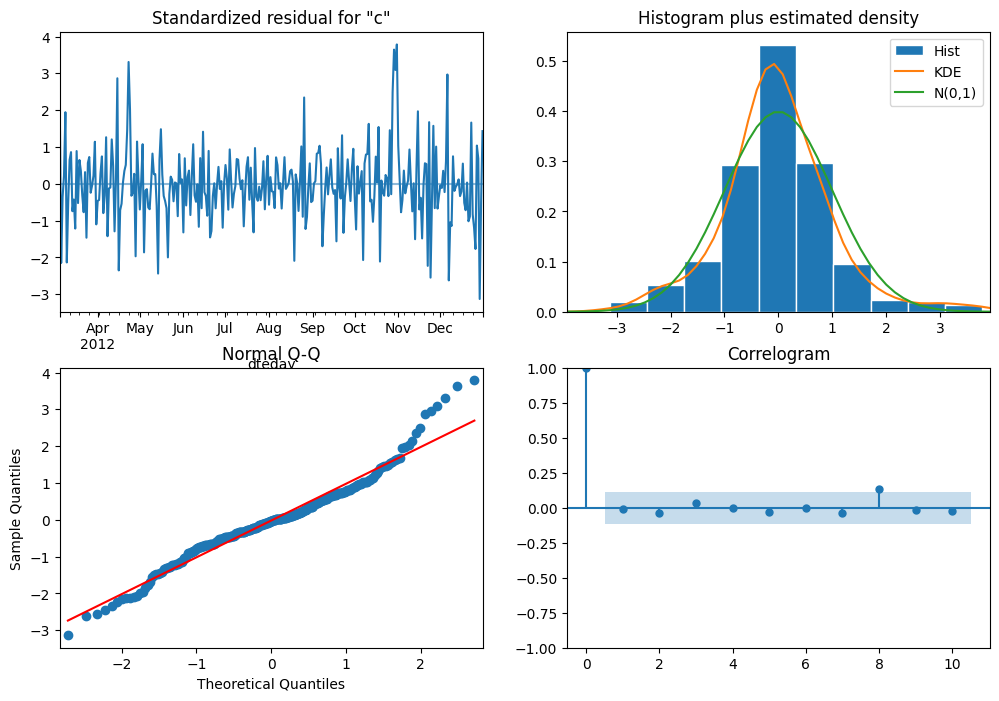

In [73]:
# Ajuste del modelo SARIMA inicial (valores iniciales basados en ACF y PACF)
model_no_outliers = SARIMAX(
    regular_diff_no_outliers,
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 30),  
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_result_no_outliers = model_no_outliers.fit(disp=False)

print(sarima_result_no_outliers.summary())

# Graficar los residuos para validar el ajuste
residuals_no_outliers = sarima_result_no_outliers.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals_no_outliers, color='blue', alpha=0.7)
plt.title('Residuos del modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals_no_outliers, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validar si los residuos son ruido blanco
sarima_result_no_outliers.plot_diagnostics(figsize=(12, 8))
plt.show()

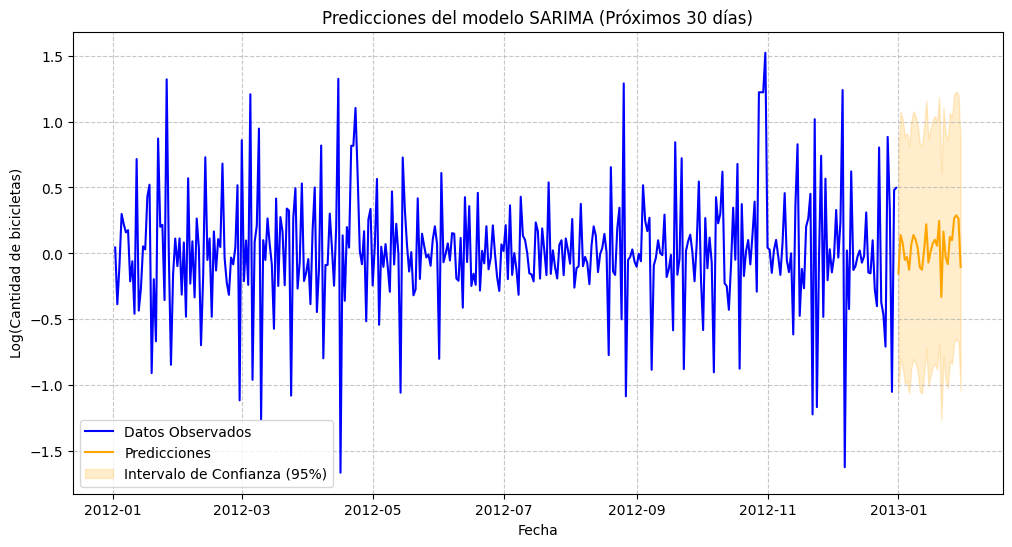

In [74]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps_no_outliers = 30  # Predecir los próximos 30 días
forecast_no_outliers = sarima_result_no_outliers.get_forecast(steps=forecast_steps_no_outliers)
forecast_ci_no_outliers = forecast_no_outliers.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(regular_diff_no_outliers, label='Datos Observados', color='blue')
plt.plot(forecast_no_outliers.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci_no_outliers.index,
    forecast_ci_no_outliers.iloc[:, 0],
    forecast_ci_no_outliers.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo SARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [75]:
y_true_no_outliers = regular_diff_no_outliers[-forecast_steps_no_outliers:]  # Valores reales
y_pred_no_outliers = forecast_no_outliers.predicted_mean  # Predicciones del modelo

mse_no_outliers = mean_squared_error(y_true_no_outliers, y_pred_no_outliers)
mae_no_outliers = mean_absolute_error(y_true_no_outliers, y_pred_no_outliers)
r2_no_outliers = r2_score(y_true_no_outliers, y_pred_no_outliers)
rmse_no_outliers = np.sqrt(mse_no_outliers)

print(f"MSE: {mse_no_outliers}, MAE: {mae_no_outliers}, R²: {r2_no_outliers}, RMSE: {rmse_no_outliers}" )

MSE: 0.3119442728947205, MAE: 0.39412105782955004, R²: -0.008879198568903623, RMSE: 0.5585197157618704


## Modelo SARIMA 2
Los resultados siguen siendo muy mejorables, vamos a probar simplificando el modelo estableciendo el parámetro Q = 0, reduciendo el riesgo de sobreajuste y facilitando la interpretación.

### Con puntos extremos

                                      SARIMAX Results                                      
Dep. Variable:                                 cnt   No. Observations:                  365
Model:             SARIMAX(1, 1, 2)x(1, 1, [], 30)   Log Likelihood                -287.386
Date:                             Tue, 14 Jan 2025   AIC                            584.772
Time:                                     12:20:36   BIC                            603.341
Sample:                                 01-02-2012   HQIC                           592.201
                                      - 12-31-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0620      0.053      1.168      0.243      -0.042       0.166
ma.L1         -2.0738      

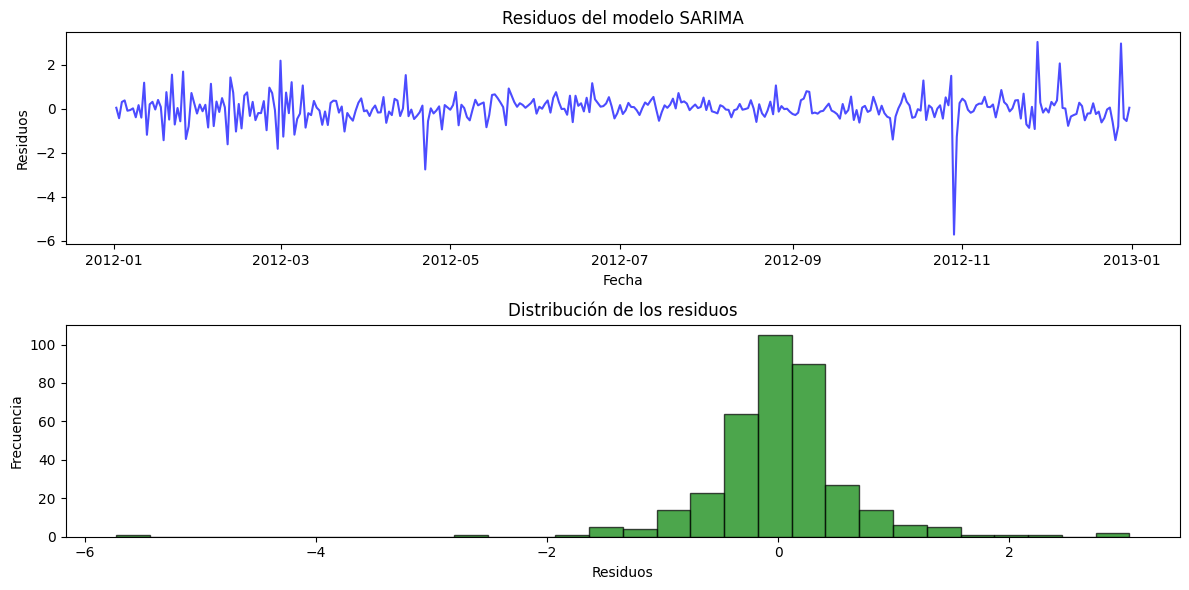

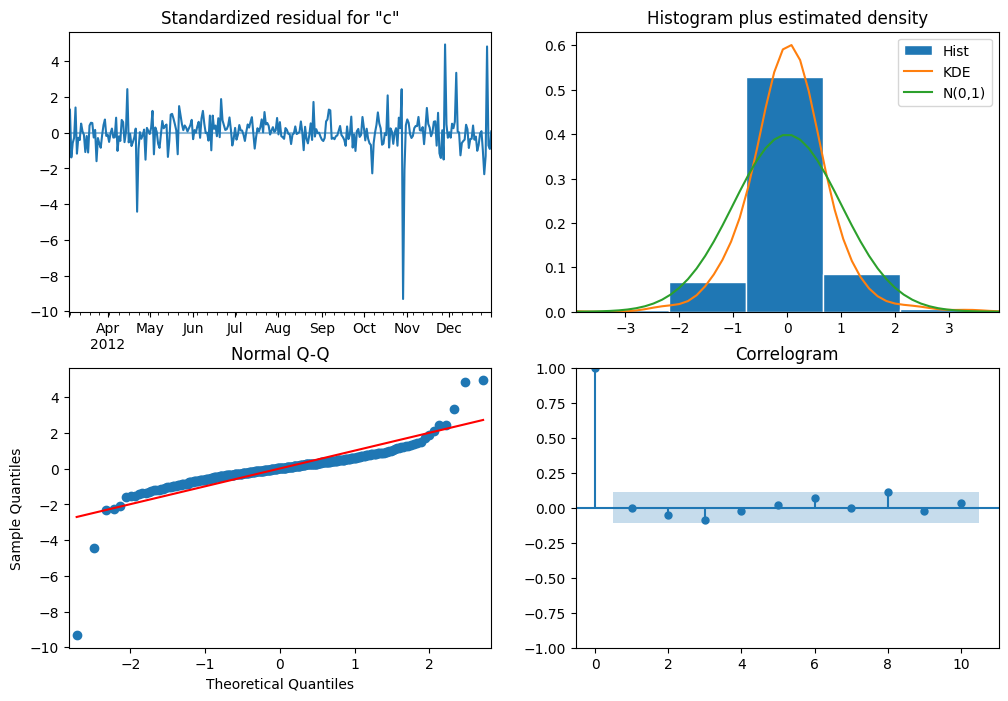

In [80]:
# Ajuste del modelo SARIMA inicial (valores iniciales basados en ACF y PACF)
model = SARIMAX(
    regular_diff,
    order=(1, 1, 2), 
    seasonal_order=(1, 1, 0, 30),  
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_result = model.fit(disp=False)

print(sarima_result.summary())

residuals = sarima_result.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals, color='blue', alpha=0.7)
plt.title('Residuos del modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validar si los residuos son ruido blanco
sarima_result.plot_diagnostics(figsize=(12, 8))
plt.show()

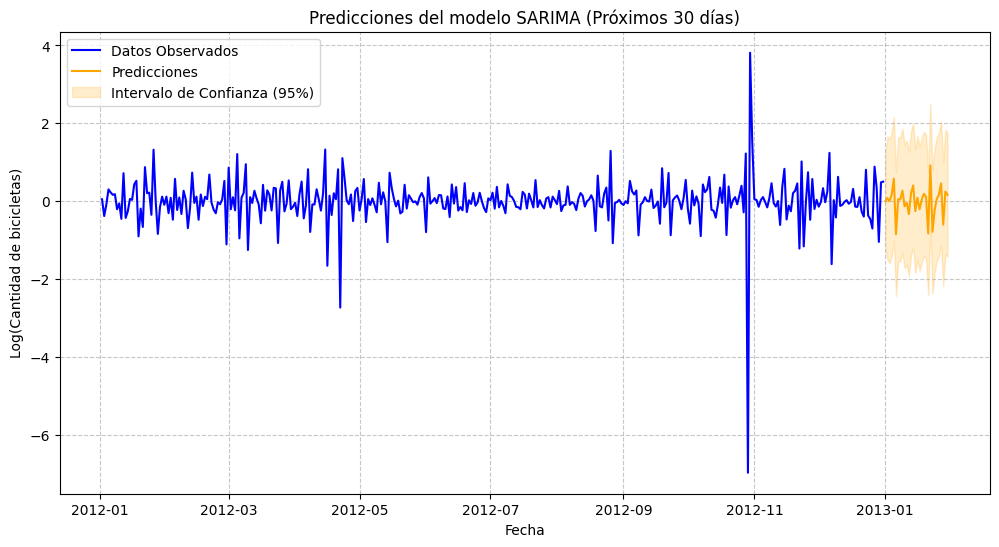

In [81]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps = 30  # Predecir los próximos 30 días
forecast = sarima_result.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(regular_diff, label='Datos Observados', color='blue')
plt.plot(forecast.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo SARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [82]:
y_true = regular_diff[-forecast_steps:]  # Valores reales
y_pred = forecast.predicted_mean  # Predicciones del modelo

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}, MAE: {mae}, R²: {r2}, RMSE: {rmse}" )

MSE: 0.13356976484886549, MAE: 0.28913326639334047, R²: 0.5680133632097819, RMSE: 0.3654719754630517


### Sin puntos extremos

                                      SARIMAX Results                                      
Dep. Variable:                                 cnt   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 30)   Log Likelihood                -240.383
Date:                             Tue, 14 Jan 2025   AIC                            488.766
Time:                                     12:36:10   BIC                            503.621
Sample:                                 01-02-2012   HQIC                           494.709
                                      - 12-31-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2566      0.045     -5.734      0.000      -0.344      -0.169
ma.L1         -1.0000     2

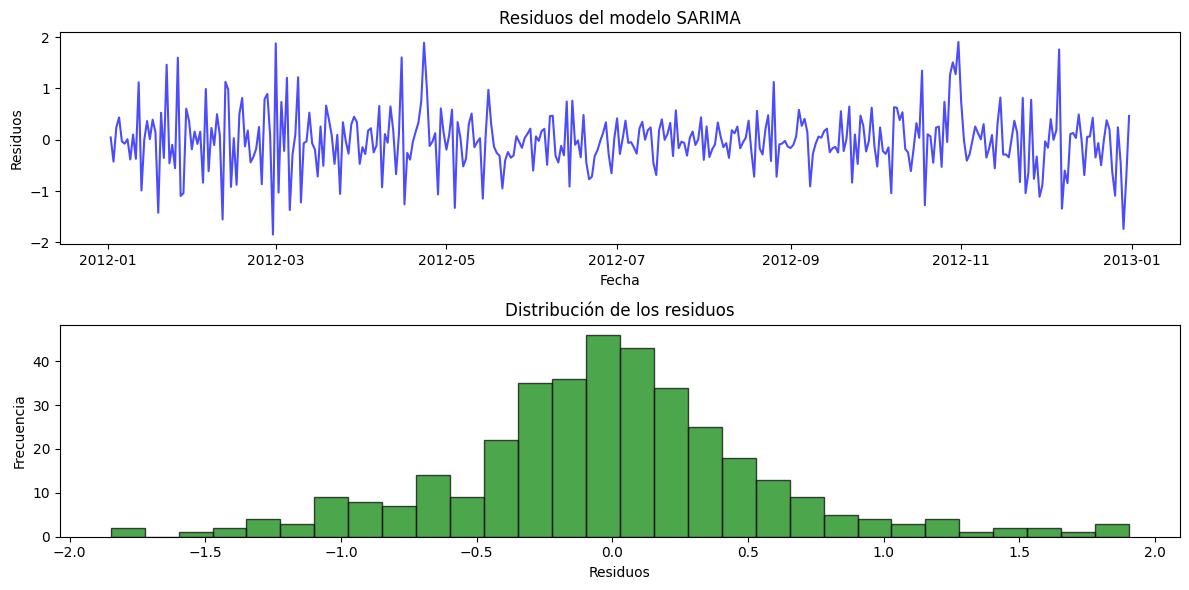

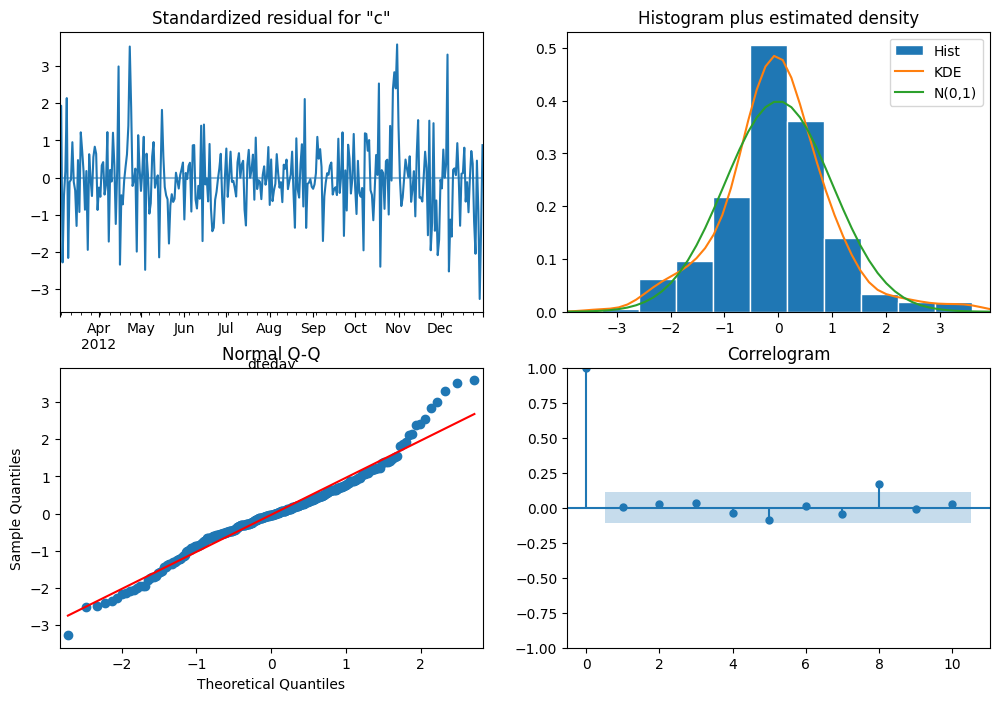

In [83]:
# Ajuste del modelo SARIMA inicial (valores iniciales basados en ACF y PACF)
model_no_outliers = SARIMAX(
    regular_diff_no_outliers,
    order=(1, 1, 1),  
    seasonal_order=(1, 1, 0, 30),  
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_result_no_outliers = model_no_outliers.fit(disp=False)

print(sarima_result_no_outliers.summary())

residuals_no_outliers = sarima_result_no_outliers.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals_no_outliers, color='blue', alpha=0.7)
plt.title('Residuos del modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals_no_outliers, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validar si los residuos son ruido blanco
sarima_result_no_outliers.plot_diagnostics(figsize=(12, 8))
plt.show()

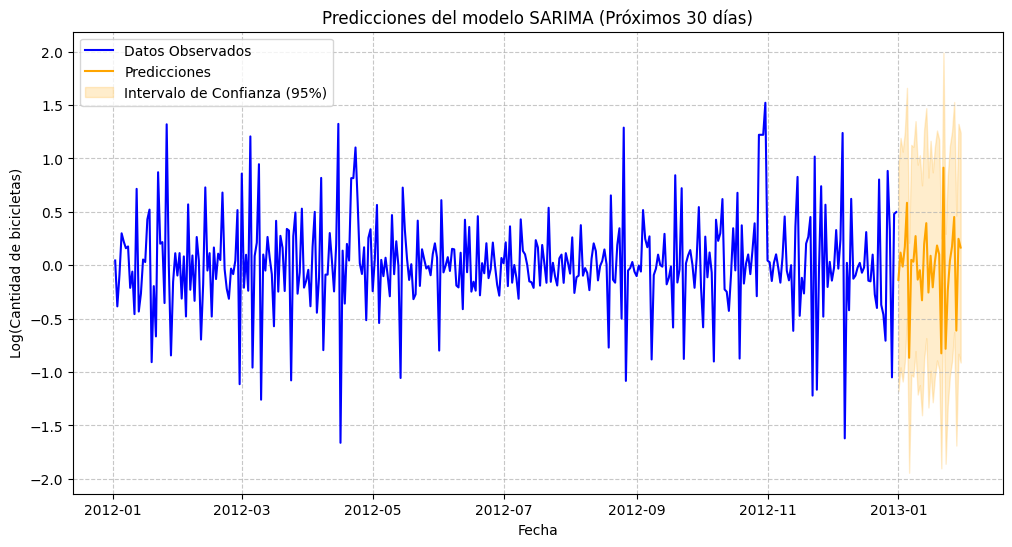

In [ ]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps_no_outliers = 30  # Predecir los próximos 30 días
forecast_no_outliers = sarima_result_no_outliers.get_forecast(steps=forecast_steps_no_outliers)
forecast_ci_no_outliers = forecast_no_outliers.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(regular_diff_no_outliers, label='Datos Observados', color='blue')
plt.plot(forecast_no_outliers.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci_no_outliers.index,
    forecast_ci_no_outliers.iloc[:, 0],
    forecast_ci_no_outliers.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo SARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [51]:
y_true_no_outliers = regular_diff_no_outliers[-forecast_steps_no_outliers:]  # Valores reales
y_pred_no_outliers = forecast_no_outliers.predicted_mean  # Predicciones del modelo

mse_no_outliers = mean_squared_error(y_true_no_outliers, y_pred_no_outliers)
mae_no_outliers = mean_absolute_error(y_true_no_outliers, y_pred_no_outliers)
r2_no_outliers = r2_score(y_true_no_outliers, y_pred_no_outliers)
rmse_no_outliers = np.sqrt(mse_no_outliers)

print(f"MSE: {mse}, MAE: {mae}, R²: {r2}, RMSE: {rmse}" )

MSE: 0.13356976484886549, MAE: 0.28913326639334047, R²: 0.5680133632097819, RMSE: 0.3654719754630517


## Modelo SARIMA 3
### Con puntos extremos

                                      SARIMAX Results                                      
Dep. Variable:                                 cnt   No. Observations:                  365
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 30)   Log Likelihood                -400.844
Date:                             Mon, 13 Jan 2025   AIC                            809.688
Time:                                     13:43:32   BIC                            824.908
Sample:                                 01-02-2012   HQIC                           815.758
                                      - 12-31-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5614      0.063     -8.844      0.000      -0.686      -0.437
ar.L2         -0.2575      

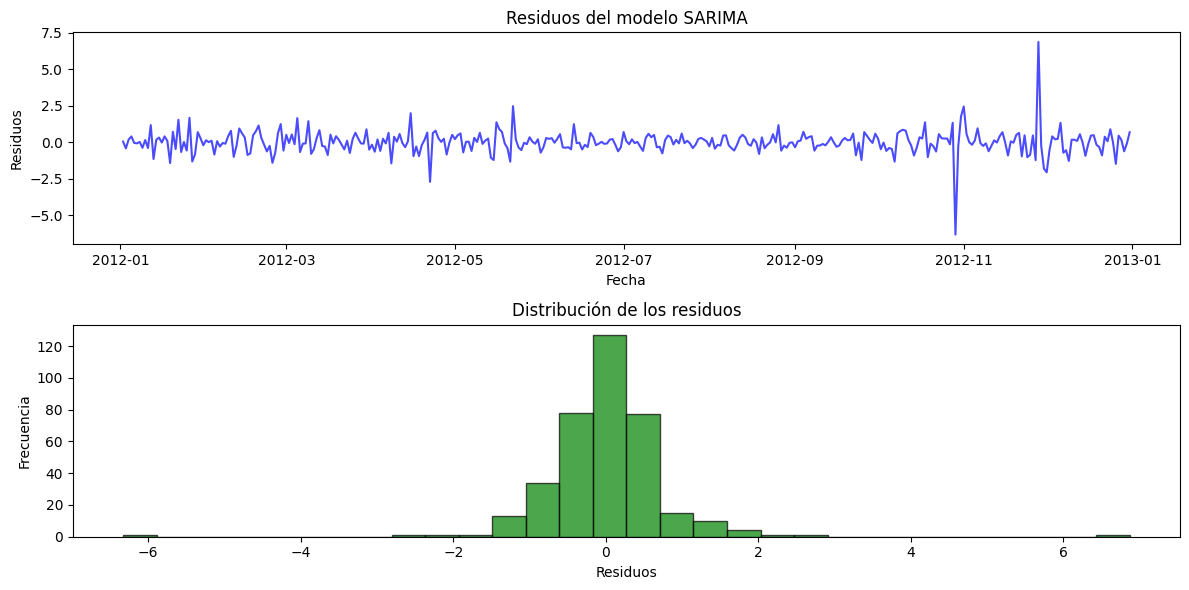

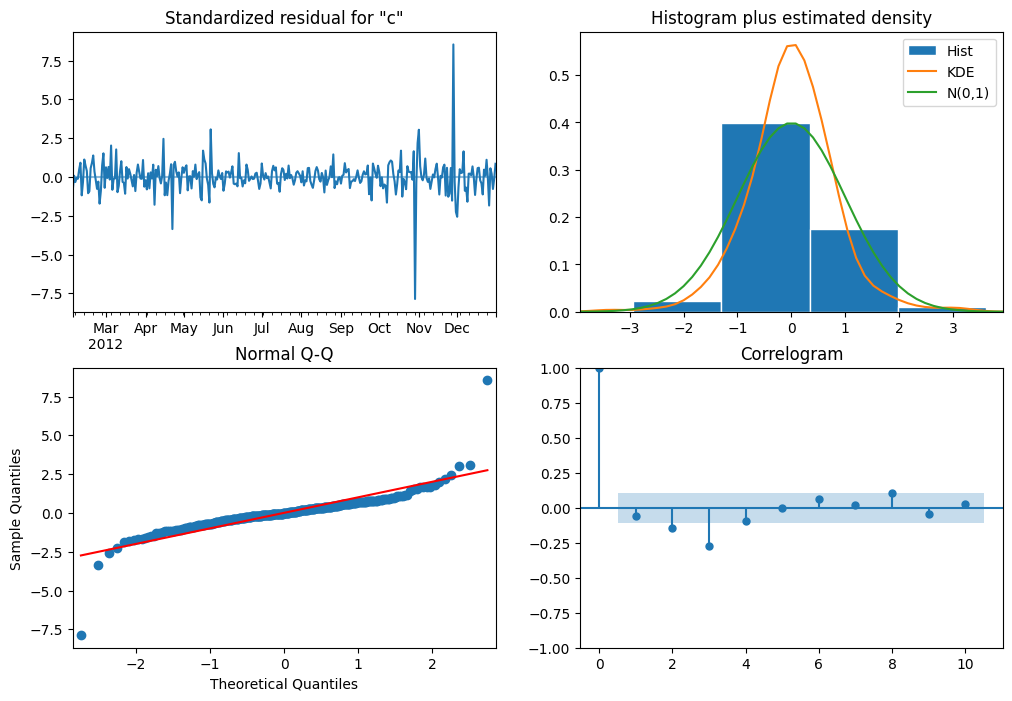

In [ ]:
# Ajuste del modelo SARIMA inicial (valores iniciales basados en ACF y PACF)
model = SARIMAX(
    regular_diff,
    order=(1, 1, 2),  # Regular: p, d, q
    seasonal_order=(0, 1, 0, 30),  # Estacional: P, D, Q, s
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_result = model.fit(disp=False)

print(sarima_result.summary())

residuals = sarima_result.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals, color='blue', alpha=0.7)
plt.title('Residuos del modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validar si los residuos son ruido blanco
sarima_result.plot_diagnostics(figsize=(12, 8))
plt.show()

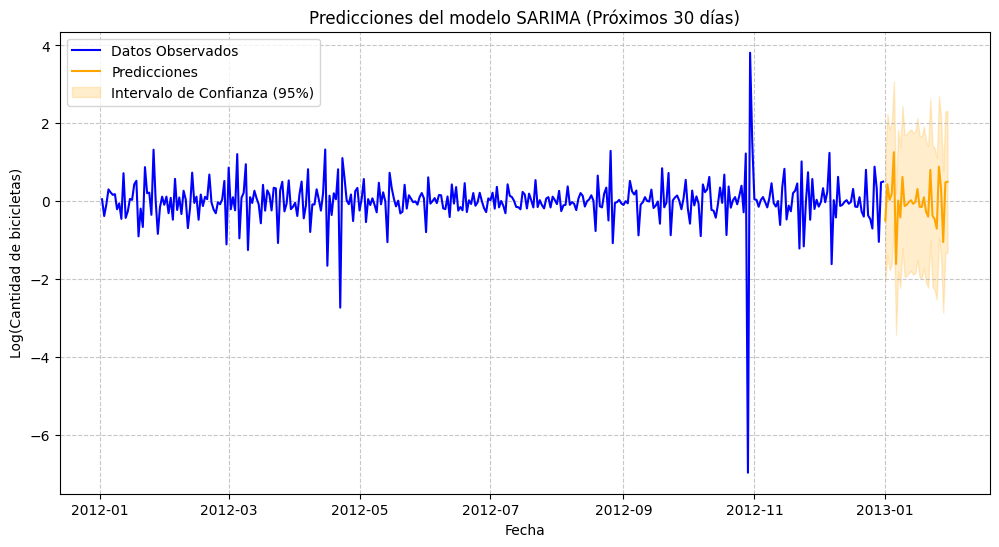

In [53]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps = 30  # Predecir los próximos 30 días
forecast = sarima_result.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

# Visualizar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(regular_diff, label='Datos Observados', color='blue')
plt.plot(forecast.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo SARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [54]:
y_true = regular_diff[-forecast_steps:]  # Valores reales
y_pred = forecast.predicted_mean  # Predicciones del modelo

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}, MAE: {mae}, R²: {r2}, RMSE: {rmse}" )

MSE: 0.008302938097308275, MAE: 0.026311487510037437, R²: 0.9731469295600542, RMSE: 0.09112045926853242


### Sin puntos extremos

                                      SARIMAX Results                                      
Dep. Variable:                                 cnt   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 30)   Log Likelihood                -315.384
Date:                             Tue, 14 Jan 2025   AIC                            636.769
Time:                                     12:45:23   BIC                            648.184
Sample:                                 01-02-2012   HQIC                           641.321
                                      - 12-31-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2699      0.044     -6.087      0.000      -0.357      -0.183
ma.L1         -1.0000     1

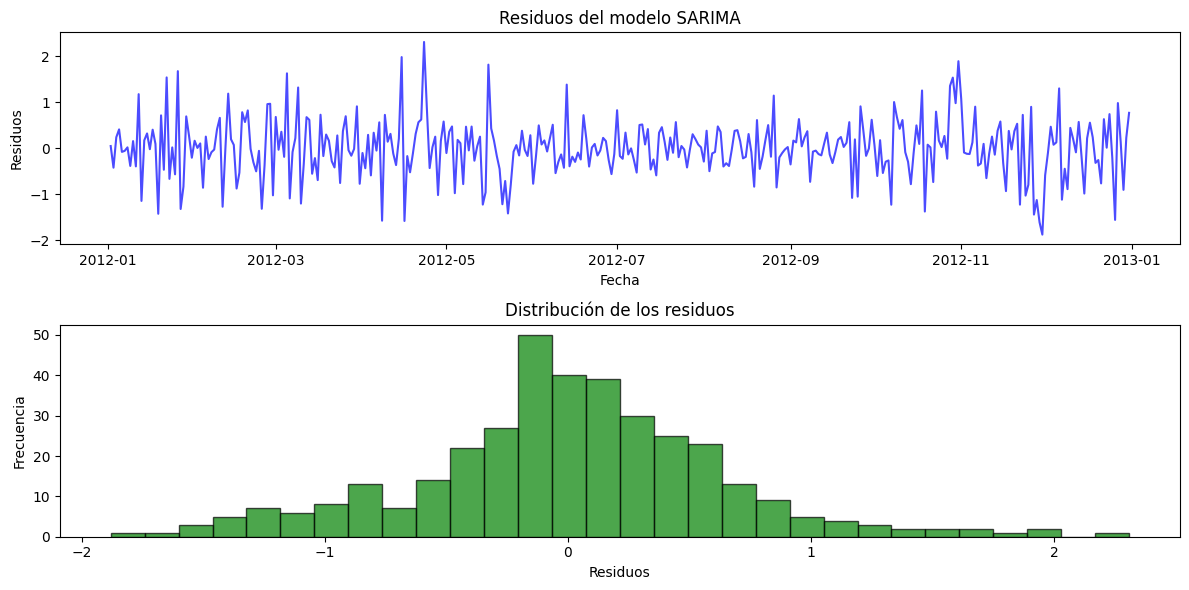

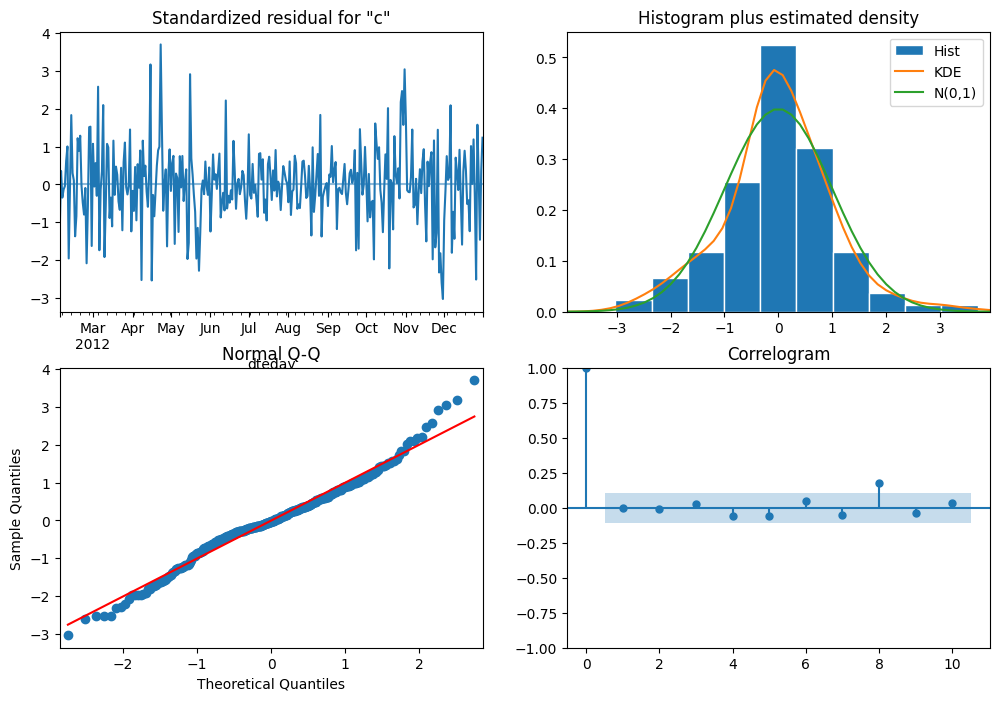

In [92]:
# Ajuste del modelo SARIMA inicial (valores iniciales basados en ACF y PACF)
model_no_outliers = SARIMAX(
    regular_diff_no_outliers,
    order=(1, 1, 1),  
    seasonal_order=(0, 1, 0, 30),  
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_result_no_outliers = model_no_outliers.fit(disp=False)

print(sarima_result_no_outliers.summary())

residuals_no_outliers = sarima_result_no_outliers.resid

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals_no_outliers, color='blue', alpha=0.7)
plt.title('Residuos del modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Residuos')

plt.subplot(2, 1, 2)
plt.hist(residuals_no_outliers, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validar si los residuos son ruido blanco
sarima_result_no_outliers.plot_diagnostics(figsize=(12, 8))
plt.show()

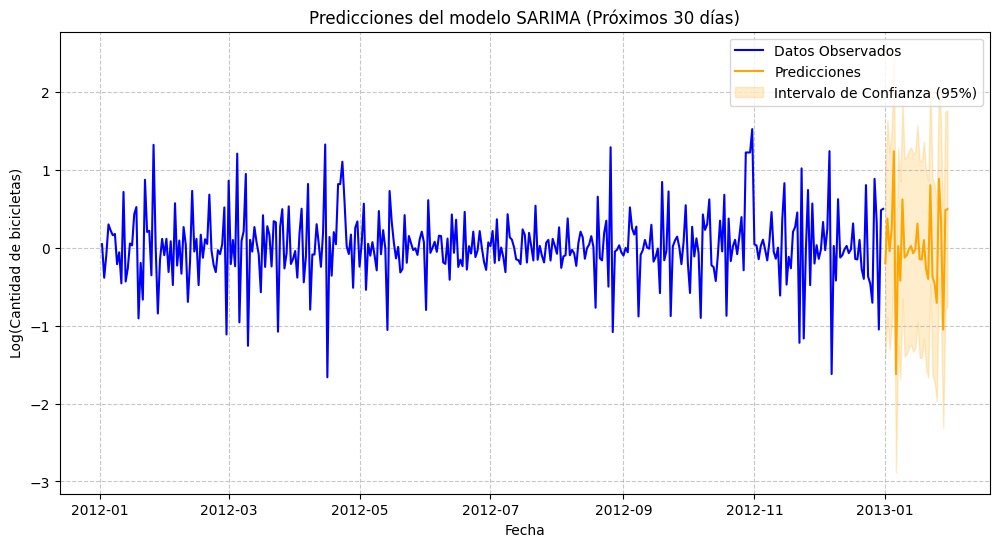

In [93]:
# Generar predicciones basadas en el modelo ajustado
forecast_steps_no_outliers = 30  # Predecir los próximos 30 días
forecast_no_outliers = sarima_result_no_outliers.get_forecast(steps=forecast_steps_no_outliers)
forecast_ci_no_outliers = forecast_no_outliers.conf_int()

# Visualizar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(regular_diff_no_outliers, label='Datos Observados', color='blue')
plt.plot(forecast_no_outliers.predicted_mean, label='Predicciones', color='orange')
plt.fill_between(
    forecast_ci_no_outliers.index,
    forecast_ci_no_outliers.iloc[:, 0],
    forecast_ci_no_outliers.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Intervalo de Confianza (95%)',
)
plt.title('Predicciones del modelo SARIMA (Próximos 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Log(Cantidad de bicicletas)')
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

In [94]:
y_true_no_outliers = regular_diff_no_outliers[-forecast_steps_no_outliers:]  # Valores reales
y_pred_no_outliers = forecast_no_outliers.predicted_mean  # Predicciones del modelo

mse_no_outliers = mean_squared_error(y_true_no_outliers, y_pred_no_outliers)
mae_no_outliers = mean_absolute_error(y_true_no_outliers, y_pred_no_outliers)
r2_no_outliers = r2_score(y_true_no_outliers, y_pred_no_outliers)
rmse_no_outliers = np.sqrt(mse_no_outliers)

print(f"MSE: {mse_no_outliers}, MAE: {mae_no_outliers}, R²: {r2_no_outliers}, RMSE: {rmse_no_outliers}" )

MSE: 0.0011002314361604592, MAE: 0.00922555721826681, R²: 0.9964416701763635, RMSE: 0.03316973675144949


## Resultados finales

| **Modelo**                         | **ARIMA**        |                | **SARIMA 1**     |                | **SARIMA 2**     |                | **SARIMA 3**     |                |
|------------------------------------|------------------|----------------|------------------|----------------|------------------|----------------|------------------|----------------|
|                                    | *Con Outliers*   | *Sin Outliers* | *Con Outliers*   | *Sin Outliers* | *Con Outliers*   | *Sin Outliers* | *Con Outliers*   | *Sin Outliers* |
| **Log Likelihood**                 | -256.680         | -213.695       | -280.958         | -211.544       | -324.433         | -239.712       | -400.844         | -320.711       |
| **AIC**                            | 521.360          | 435.390        | 573.915          | 435.089        | 658.866          | 489.423        | 809.688          | 643.422        |
| **BIC**                            | 536.948          | 450.979        | 596.178          | 457.351        | 677.418          | 507.975        | 824.908          | 661.974        |
| **HQIC**                           | 527.555          | 441.586        | 582.823          | 443.996        | 666.289          | 496.846        | 815.758          | 650.845        |
| **Ljung-Box (L1, Prob(Q))**        | 0.00 (0.97)      | 0.00 (0.95)    | 1.90 (0.17)      | 0.00 (0.96)    | 1.74 (0.19)      | 0.00 (0.99)    | 1.08 (0.30)      | 0.00 (0.80)    |
| **Jarque-Bera (JB, Prob)**         | 55327.28 (0.00)  | 107.84 (0.00)  | 28329.76 (0.00)  | 62.29 (0.00)   | 8450.00 (0.00)   | 34.60 (0.00)   | 9716.42 (0.00)   | 43.70 (0.00)   |
| **Heterocedasticidad (H)**         | 2.24 (0.00)      | 1.14 (0.48)    | 3.13 (0.00)      | 1.42 (0.08)    | 3.19 (0.00)      | 1.31 (0.18)    | 2.40 (0.00)      | 1.12 (0.21)    |
| **Kurtosis**                       | 62.59            | 5.45           | 49.70            | 5.05           | 28.75            | 4.57           | 29.49            | 4.11           |
| **Skew**                           | -4.92            | 0.52           | -4.20            | 0.44           | -1.45            | 0.26           | 0.41             | 0.15           |
| **Desviación estándar (`sigma2`)** | 0.2316           | 0.1860         | 0.2901           | 0.2102         | 0.4935           | 0.2819         | 0.6448           | 0.3127         |
| **MSE**                            | 0.3094           | 0.3099         | 0.4546           | 0.3124         | 0.1281           | 0.1281         | 0.0083           | 0.0028         |
| **MAE**                            | 0.3959           | 0.4000         | 0.4893           | 0.3954         | 0.2908           | 0.2908         | 0.0263           | 0.0127         |
| **R<sup>2</sup>**                  | -0.0006          | -0.0022        | -0.4701          | -0.0103        | 0.5858           | 0.5858         | 0.9731           | 0.9904         |
| **RMSE**                           | 0.5562           | 0.5567         | 0.6742           | 0.5589         | 0.3579           | 0.3579         | 0.0911           | 0.0530         |
